---
## 1. Librairies et constantes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import gc
import os
from scipy.optimize import curve_fit

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

Rd      = 287.05
Rv      = 461.5
EPSILON = Rd / Rv

DIR_3D = '3D'
DIR_2D = '2D'
DIR_1D = '1D'

def path3d(var):
    return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')

def path2d(var):
    return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{var}.nc')

def path1d(var):
    return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{var}.nc')

BLOC = 2
dx   = 2000.0
dy   = 2000.0

print('Prêt.')

Prêt.


---
## 2. Dimensions de la grille

In [2]:
_ds = xr.open_dataset(path3d('ua'))
_da = _ds['ua']

dim_t = _da.dims[0]
dim_z = _da.dims[1]
dim_y = _da.dims[2]
dim_x = _da.dims[3]

n_t = _da.sizes[dim_t]
n_z = _da.sizes[dim_z]
n_y = _da.sizes[dim_y]
n_x = _da.sizes[dim_x]
times = _da[dim_t].values.copy()

_ds.close()
del _ds, _da
gc.collect()

# altitude depuis le fichier 1D (valeurs en mètres)
_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.copy()
_ds1.close()
del _ds1
gc.collect()

t_stat   = int(2 * n_t / 3)
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat
time_days = times.astype('float64') // 4

print(f'Grille : {n_t} t  x  {n_z} z  x  {n_y} y  x  {n_x} x')
print(f'Altitude : {alt[0]:.0f} — {alt[-1]:.0f} m')
print(f'État stationnaire : t={t_stat} → {n_t-1}  ({n_stat} pas)')

Grille : 100 t  x  74 z  x  128 y  x  2000 x
Altitude : 0 — 32500 m
État stationnaire : t=66 → 99  (34 pas)


---
## 3. Masques humide / sec (PRW)

In [3]:
ds_prw   = xr.open_dataset(path2d('prw'))
prw_all  = ds_prw['prw'].load()
ds_prw.close()

prw_mean  = prw_all.isel({dim_t: idx_stat}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))

mh = (prw_mean.values > PRW_SEUIL)
ms = ~mh

del prw_all
gc.collect()

print(f'Seuil PRW : {PRW_SEUIL:.1f} kg/m²')
print(f'Humide : {mh.mean()*100:.1f}%   Sec : {ms.mean()*100:.1f}%')

Seuil PRW : 30.4 kg/m²
Humide : 42.3%   Sec : 57.7%


---
## 4. Profil ρ₀

In [4]:
rho0_sum = np.zeros(n_z)
n_rho    = 0

ds_ta  = xr.open_dataset(path3d('ta'))
ds_pa  = xr.open_dataset(path3d('pa'))
ds_hus = xr.open_dataset(path3d('hus'))

for t0 in range(t_stat, n_t, BLOC):
    t1     = min(t0 + BLOC, n_t)
    sl     = {dim_t: slice(t0, t1)}
    T_blk  = ds_ta['ta'].isel(sl).values
    p_blk  = ds_pa['pa'].isel(sl).values
    qv_blk = ds_hus['hus'].isel(sl).values
    Tv_blk = T_blk * (1.0 + qv_blk / EPSILON) / (1.0 + qv_blk)
    rho_blk = p_blk / (Rd * Tv_blk)
    rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)
    n_rho    += (t1 - t0)
    del T_blk, p_blk, qv_blk, Tv_blk, rho_blk
    gc.collect()

ds_ta.close() ; ds_pa.close() ; ds_hus.close()
del ds_ta, ds_pa, ds_hus
gc.collect()

rho0 = rho0_sum / n_rho

print(f'ρ₀ calculé sur {n_rho} pas de temps.')
print(f'  Surface : {rho0[0]:.3f} kg/m³')
print(f'  ~10 km  : {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m³')

ρ₀ calculé sur 34 pas de temps.
  Surface : 1.183 kg/m³
  ~10 km  : 0.410 kg/m³


# §17 — Paramétrisation polynome flux de reynolds — Notebook autonome
Recalcule tout depuis zéro : imports, dimensions, ρ₀, masques humide/sec, flux de Reynolds par région, puis fit analytique.

---
## 5. Fonction utilitaire

In [5]:
def tendance(flux_profil):
    """Force de Reynolds : -1/rho0 · d(rho0 <u'w'>) / dz"""
    return -np.gradient(flux_profil, alt) / rho0

---
## 6. Calcul des flux de Reynolds par région (§16)

Calcule `flux_loc_h/s` (anomalies intra-région) et `flux_glob_h/s` (anomalies domaine entier)  
niveau par niveau pour économiser la RAM.

In [6]:
flux_loc_h  = np.zeros(n_z)
flux_loc_s  = np.zeros(n_z)
flux_glob_h = np.zeros(n_z)
flux_glob_s = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):

    acc_loc_h  = 0.0 ; acc_loc_s  = 0.0
    acc_glob_h = 0.0 ; acc_glob_s = 0.0
    n = 0

    for it in range(t_stat, n_t):

        u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values

        # anomalies locales (intra-région)
        u_h = u_2d[mh] ; u_s = u_2d[ms]
        w_h = w_2d[mh] ; w_s = w_2d[ms]
        acc_loc_h += ((u_h - u_h.mean()) * (w_h - w_h.mean())).mean()
        acc_loc_s += ((u_s - u_s.mean()) * (w_s - w_s.mean())).mean()

        # anomalies globales (domaine entier)
        u_p = u_2d - u_2d.mean()
        w_p = w_2d - w_2d.mean()
        acc_glob_h += (u_p * w_p)[mh].mean()
        acc_glob_s += (u_p * w_p)[ms].mean()

        n += 1
        del u_2d, w_2d, u_h, u_s, w_h, w_s, u_p, w_p
        gc.collect()

    flux_loc_h[iz]  = rho0[iz] * acc_loc_h  / n
    flux_loc_s[iz]  = rho0[iz] * acc_loc_s  / n
    flux_glob_h[iz] = rho0[iz] * acc_glob_h / n
    flux_glob_s[iz] = rho0[iz] * acc_glob_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

print('Flux calculés.')

  iz=0/73  (0 m)
  iz=10/73  (1331 m)
  iz=20/73  (6000 m)
  iz=30/73  (11000 m)
  iz=40/73  (16000 m)
  iz=50/73  (21000 m)
  iz=60/73  (26000 m)
  iz=70/73  (31000 m)
Flux calculés.


---
## §17 — Étape 1 : visualisation du profil de référence

Observer : zéros en surface et au sommet convectif, localisation de l'extremum, changement de signe éventuel.

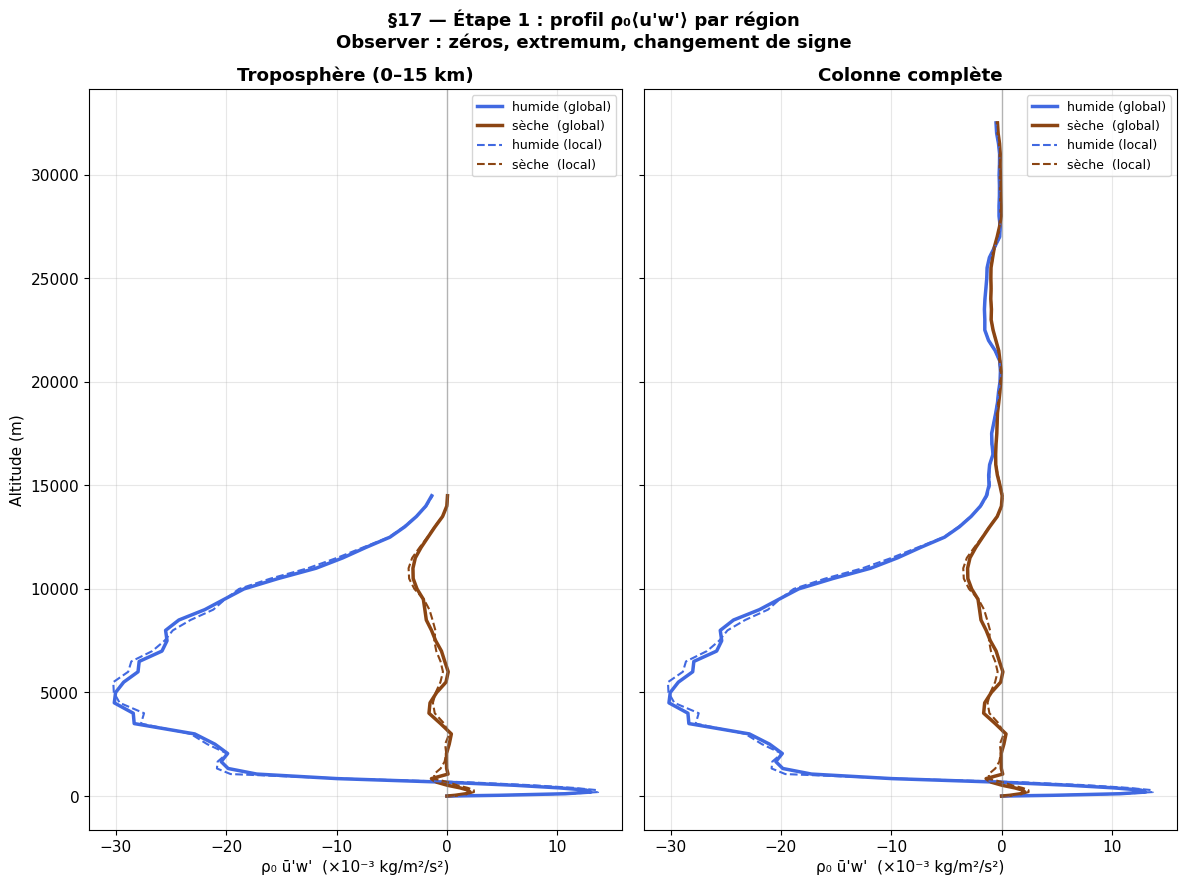

── Région HUMIDE (global) ──
  min  : -30.1505 ×10⁻³  à z = 4500 m
  max  : 13.0515 ×10⁻³  à z = 194 m
  surface (iz=0)   : 0.0000 ×10⁻³
  z≈15 km          : -1.1430 ×10⁻³

── Région SÈCHE  (global) ──
  min  : -3.0802 ×10⁻³  à z = 11000 m
  max  : 2.1031 ×10⁻³  à z = 194 m
  surface (iz=0)   : 0.0000 ×10⁻³
  z≈15 km          : -0.1504 ×10⁻³



In [7]:
idx_tropo = np.searchsorted(alt, 15000)
sc = 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl], color='royalblue',   lw=2.5, label='humide (global)')
    ax.plot(flux_glob_s[sl] * sc, alt[sl], color='saddlebrown', lw=2.5, label='sèche  (global)')
    ax.plot(flux_loc_h[sl]  * sc, alt[sl], color='royalblue',   lw=1.5, linestyle='--', label='humide (local)')
    ax.plot(flux_loc_s[sl]  * sc, alt[sl], color='saddlebrown', lw=1.5, linestyle='--', label='sèche  (local)')
    ax.axvline(0, color='grey', alpha=0.5, lw=1)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(
    '§17 — Étape 1 : profil ρ₀⟨u\'w\'⟩ par région\n'
    'Observer : zéros, extremum, changement de signe',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

for label, flux in [('HUMIDE (global)', flux_glob_h), ('SÈCHE  (global)', flux_glob_s)]:
    phi = flux[:idx_tropo]
    iz_min = np.argmin(phi)
    iz_max = np.argmax(phi)
    print(f'── Région {label} ──')
    print(f'  min  : {phi[iz_min]*sc:.4f} ×10⁻³  à z = {alt[iz_min]:.0f} m')
    print(f'  max  : {phi[iz_max]*sc:.4f} ×10⁻³  à z = {alt[iz_max]:.0f} m')
    print(f'  surface (iz=0)   : {flux[0]*sc:.4f} ×10⁻³')
    print(f'  z≈15 km          : {flux[idx_tropo]*sc:.4f} ×10⁻³')
    print()

---
## §17 — Étape 2 : forme analytique

$$\rho_0\,\overline{u'w'}(z) = A \cdot \frac{z}{z_c} \cdot \left(1 - \frac{z}{z_c}\right)^n, \quad z \leq z_c$$

- $A$ : amplitude (kg/m²/s²)
- $z_c$ : hauteur du sommet convectif (m)
- $n$ : asymétrie — le max se trouve à $z^* = z_c / (1+n)$

/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in sqrt
  val = A * xi * (1.0 - xi)**n
/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


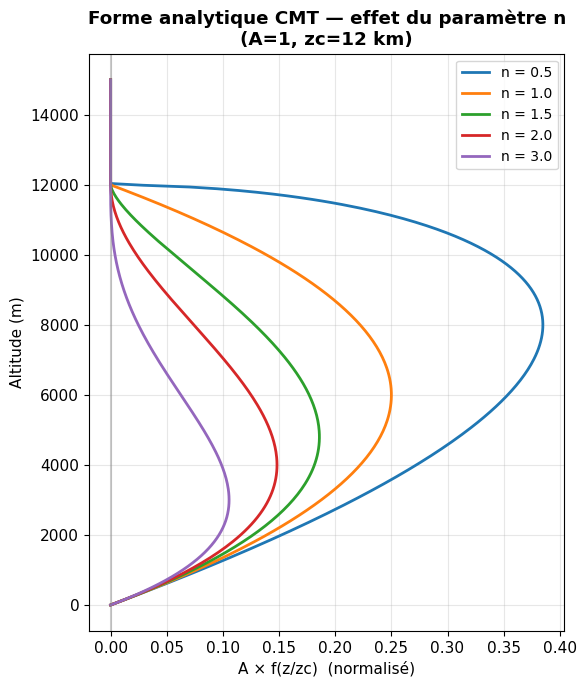

In [8]:
def profil_cmt(z, A, zc, n):
    z  = np.asarray(z, dtype=float)
    xi = np.clip(z / zc, 0.0, 1.0)   # borne [0,1] : pas de (base<0)**n -> pas de RuntimeWarning
    return A * xi * (1.0 - xi)**n

z_test  = np.linspace(0, 15000, 300)

fig, ax = plt.subplots(figsize=(6, 7))
for n_test in [0.5, 1.0, 1.5, 2.0, 3.0]:
    ax.plot(profil_cmt(z_test, A=1.0, zc=12000.0, n=n_test), z_test, lw=2, label=f'n = {n_test}')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('A × f(z/zc)  (normalisé)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Forme analytique CMT — effet du paramètre n\n(A=1, zc=12 km)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## §17 — Étape 3 : fit scipy — région humide

In [9]:
z_fit   = alt[:idx_tropo].astype(float)
phi_fit = flux_glob_h[:idx_tropo]

p0 = [phi_fit.min(), 12000.0, 1.5]

popt_h, _ = curve_fit(profil_cmt, z_fit, phi_fit, p0=p0, maxfev=20000)
A_h, zc_h, n_h = popt_h

print('── Fit région HUMIDE ──')
print(f'  A  = {A_h:.4e} kg/m²/s²')
print(f'  zc = {zc_h/1000:.2f} km')
print(f'  n  = {n_h:.3f}')

── Fit région HUMIDE ──
  A  = -1.6696e-01 kg/m²/s²
  zc = 14.44 km
  n  = 1.609


/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


---
## §17 — Étape 4 : R² et résidus

R² humide = 0.8266
Résidu max : 15.8543 ×10⁻³ kg/m²/s²
Résidu rms : 5.6045 ×10⁻³ kg/m²/s²


/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


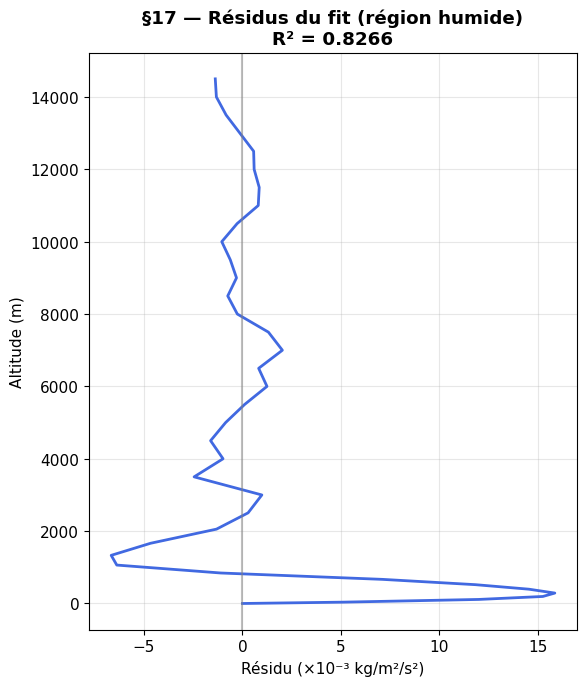

In [10]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1.0 - ss_res / ss_tot

phi_pred_h = profil_cmt(z_fit, *popt_h)
R2_h       = r2_score(phi_fit, phi_pred_h)
residus_h  = phi_fit - phi_pred_h

print(f'R² humide = {R2_h:.4f}')
print(f'Résidu max : {np.abs(residus_h).max()*sc:.4f} ×10⁻³ kg/m²/s²')
print(f'Résidu rms : {np.sqrt((residus_h**2).mean())*sc:.4f} ×10⁻³ kg/m²/s²')

fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(residus_h * sc, z_fit, color='royalblue', lw=2)
ax.axvline(0, color='grey', alpha=0.5)
ax.set_xlabel('Résidu (×10⁻³ kg/m²/s²)')
ax.set_ylabel('Altitude (m)')
ax.set_title(f'§17 — Résidus du fit (région humide)\nR² = {R2_h:.4f}', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## §17 — Étape 5 : visualisation simulation vs fit

/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


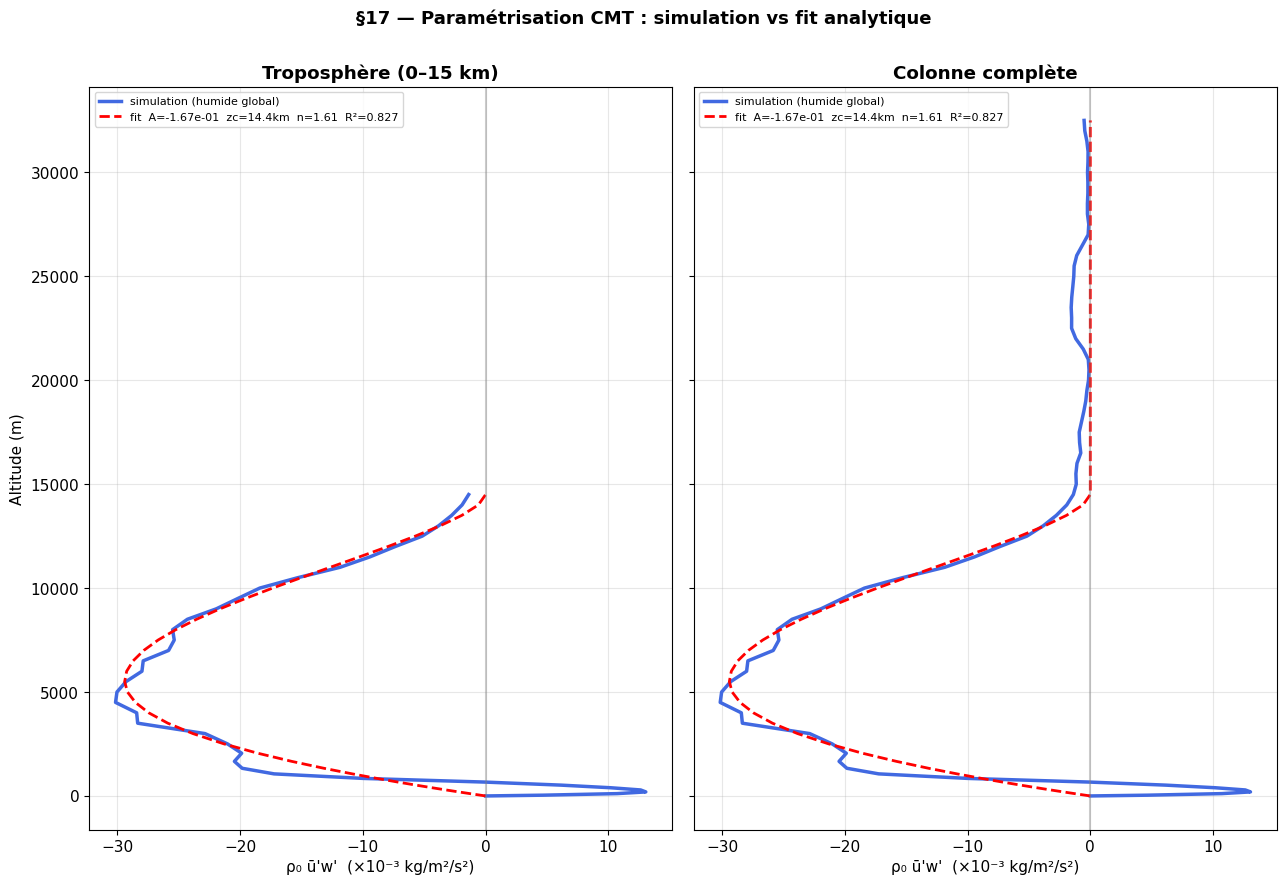

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl],
            color='royalblue', lw=2.5, label='simulation (humide global)')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_h) * sc, alt[sl],
            color='red', lw=2, linestyle='--',
            label=f'fit  A={A_h:.2e}  zc={zc_h/1e3:.1f}km  n={n_h:.2f}  R²={R2_h:.3f}')
    ax.axvline(0, color='grey', alpha=0.4)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(
    '§17 — Paramétrisation CMT : simulation vs fit analytique\n',
    
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## §17 — Étape 6 : fit sur la région sèche + comparaison

/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


── Fit région SÈCHE ──
  A  = -2.4129e-03 kg/m²/s²
  zc = 13.00 km
  n  = -0.036
  R² = 0.5676


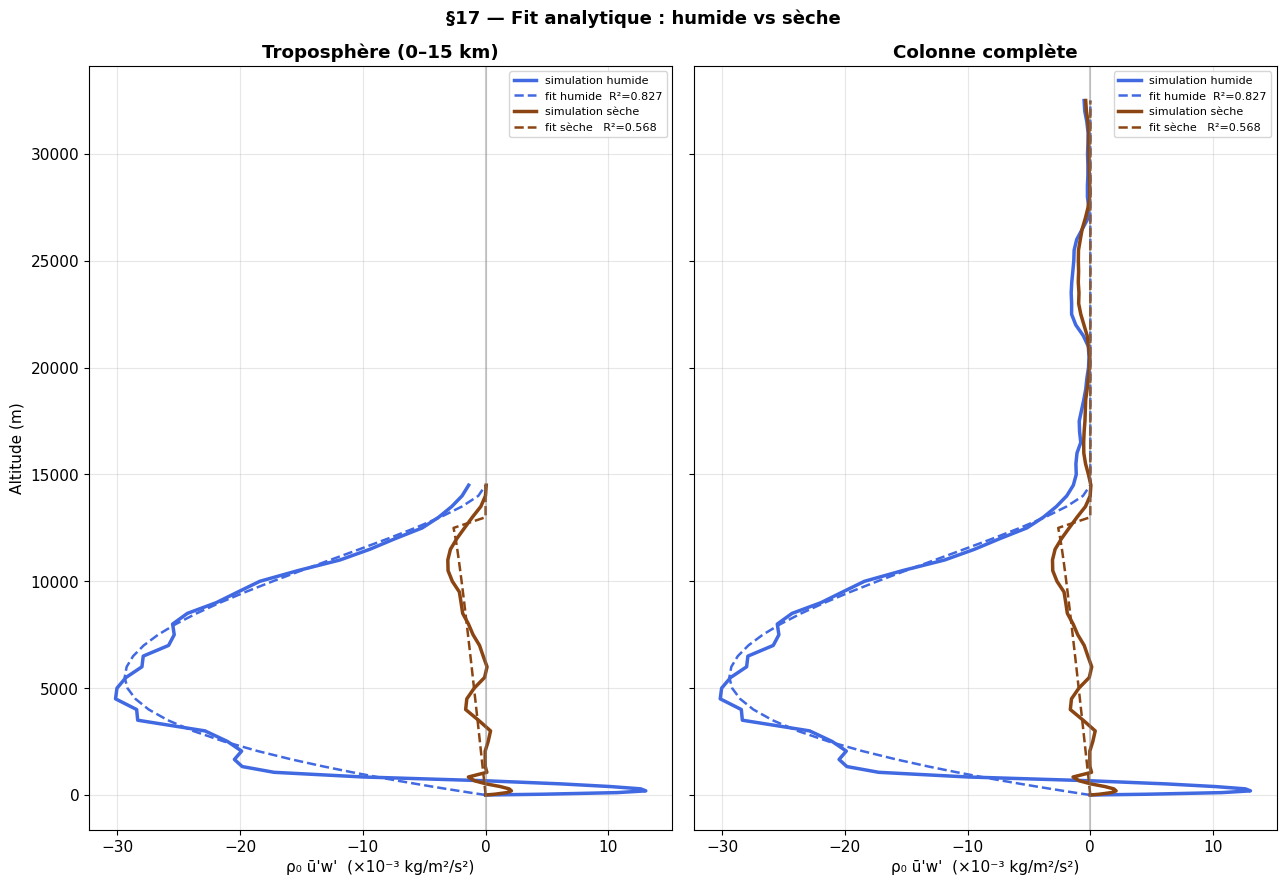

In [12]:
phi_fit_s = flux_glob_s[:idx_tropo]
p0_s = [phi_fit_s.min(), 12000.0, 1.5]

popt_s, _ = curve_fit(profil_cmt, z_fit, phi_fit_s, p0=p0_s, maxfev=20000)
A_s, zc_s, n_s = popt_s

R2_s = r2_score(phi_fit_s, profil_cmt(z_fit, *popt_s))

print('── Fit région SÈCHE ──')
print(f'  A  = {A_s:.4e} kg/m²/s²')
print(f'  zc = {zc_s/1000:.2f} km')
print(f'  n  = {n_s:.3f}')
print(f'  R² = {R2_s:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

for ax, sl, titre in zip(
    axes,
    [slice(None, idx_tropo), slice(None)],
    ['Troposphère (0–15 km)', 'Colonne complète'],
):
    ax.plot(flux_glob_h[sl] * sc, alt[sl], color='royalblue',   lw=2.5, label='simulation humide')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_h) * sc, alt[sl],
            color='royalblue', lw=1.8, linestyle='--', label=f'fit humide  R²={R2_h:.3f}')
    ax.plot(flux_glob_s[sl] * sc, alt[sl], color='saddlebrown', lw=2.5, label='simulation sèche')
    ax.plot(profil_cmt(alt[sl].astype(float), *popt_s) * sc, alt[sl],
            color='saddlebrown', lw=1.8, linestyle='--', label=f'fit sèche   R²={R2_s:.3f}')
    ax.axvline(0, color='grey', alpha=0.4)
    ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle('§17 — Fit analytique : humide vs sèche', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## §17 — Étape 7 : tableau de synthèse

In [13]:
z_max_h = zc_h / (1 + n_h)
z_max_s = zc_s / (1 + n_s)

print('=' * 55)
print(f'{"Paramètre":<22} {"Humide":>14} {"Sèche":>14}')
print('=' * 55)
print(f'{"A (kg/m²/s²)":<22} {A_h:>14.4e} {A_s:>14.4e}')
print(f'{"zc (km)":<22} {zc_h/1000:>14.2f} {zc_s/1000:>14.2f}')
print(f'{"n":<22} {n_h:>14.3f} {n_s:>14.3f}')
print(f'{"R²":<22} {R2_h:>14.4f} {R2_s:>14.4f}')
print(f'{"z_max = zc/(1+n) (km)":<22} {z_max_h/1000:>14.2f} {z_max_s/1000:>14.2f}')
print('=' * 55)

Paramètre                      Humide          Sèche
A (kg/m²/s²)              -1.6696e-01    -2.4129e-03
zc (km)                         14.44          13.00
n                               1.609         -0.036
R²                             0.8266         0.5676
z_max = zc/(1+n) (km)            5.54          13.49


---
## §17 — Étape 8 : robustesse temporelle (early vs late)

  iz=0/73
  iz=10/73
  iz=20/73
  iz=30/73
  iz=40/73
  iz=50/73
  iz=60/73
  iz=70/73

             A (kg/m²/s²)    zc (km)        n       R²
early         -1.5624e-01      14.94    1.691   0.7995
late          -1.7586e-01      13.97    1.519   0.8279
full          -1.6696e-01      14.44    1.609   0.8266


/tmp/ipykernel_5754/631635325.py:3: RuntimeWarning: invalid value encountered in power
  val = A * xi * (1.0 - xi)**n


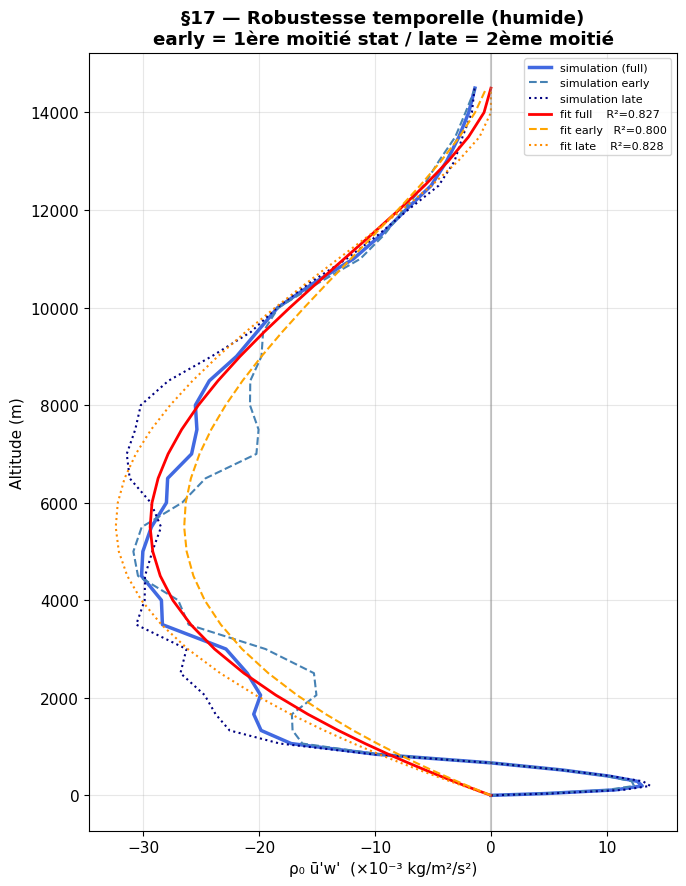

In [14]:
t_mid = t_stat + (n_t - t_stat) // 2

flux_early_h = np.zeros(n_z)
flux_late_h  = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    for flux_arr, t0, t1 in [
        (flux_early_h, t_stat, t_mid),
        (flux_late_h,  t_mid,  n_t),
    ]:
        acc = 0.0
        n   = 0
        for it in range(t0, t1):
            u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
            w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values
            u_p  = u_2d - u_2d.mean()
            w_p  = w_2d - w_2d.mean()
            acc += (u_p * w_p)[mh].mean()
            n   += 1
            del u_2d, w_2d, u_p, w_p
        flux_arr[iz] = rho0[iz] * acc / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

popt_early, _ = curve_fit(profil_cmt, z_fit, flux_early_h[:idx_tropo], p0=p0, maxfev=20000)
popt_late,  _ = curve_fit(profil_cmt, z_fit, flux_late_h[:idx_tropo],  p0=p0, maxfev=20000)

R2_early = r2_score(flux_early_h[:idx_tropo], profil_cmt(z_fit, *popt_early))
R2_late  = r2_score(flux_late_h[:idx_tropo],  profil_cmt(z_fit, *popt_late))

print()
print(f'{"":<8} {"A (kg/m²/s²)":>16} {"zc (km)":>10} {"n":>8} {"R²":>8}')
print(f'{"early":<8} {popt_early[0]:>16.4e} {popt_early[1]/1e3:>10.2f} {popt_early[2]:>8.3f} {R2_early:>8.4f}')
print(f'{"late":<8} {popt_late[0]:>16.4e} {popt_late[1]/1e3:>10.2f} {popt_late[2]:>8.3f} {R2_late:>8.4f}')
print(f'{"full":<8} {A_h:>16.4e} {zc_h/1e3:>10.2f} {n_h:>8.3f} {R2_h:>8.4f}')

fig, ax = plt.subplots(figsize=(7, 9))
ax.plot(flux_glob_h[:idx_tropo]   * sc, z_fit, color='royalblue',  lw=2.5, label='simulation (full)')
ax.plot(flux_early_h[:idx_tropo]  * sc, z_fit, color='steelblue',  lw=1.5, linestyle='--', label='simulation early')
ax.plot(flux_late_h[:idx_tropo]   * sc, z_fit, color='navy',       lw=1.5, linestyle=':',  label='simulation late')
ax.plot(profil_cmt(z_fit, *popt_h)     * sc, z_fit, color='red',       lw=2,   label=f'fit full    R²={R2_h:.3f}')
ax.plot(profil_cmt(z_fit, *popt_early) * sc, z_fit, color='orange',    lw=1.5, linestyle='--', label=f'fit early   R²={R2_early:.3f}')
ax.plot(profil_cmt(z_fit, *popt_late)  * sc, z_fit, color='darkorange', lw=1.5, linestyle=':', label=f'fit late    R²={R2_late:.3f}')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('ρ₀ ū\'w\'  (×10⁻³ kg/m²/s²)')
ax.set_ylabel('Altitude (m)')
ax.set_title('§17 — Robustesse temporelle (humide)\nearly = 1ère moitié stat / late = 2ème moitié', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Profil des vents u et v par région

In [15]:
lux_loc_h  = np.zeros(n_z)
flux_loc_s  = np.zeros(n_z)
flux_glob_h = np.zeros(n_z)
flux_glob_s = np.zeros(n_z)
ubar_h      = np.zeros(n_z)
ubar_s      = np.zeros(n_z)
vbar_h      = np.zeros(n_z)
vbar_s      = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z//2):

    acc_loc_h  = 0.0 ; acc_loc_s  = 0.0
    acc_glob_h = 0.0 ; acc_glob_s = 0.0
    acc_ubar_h = 0.0 ; acc_ubar_s = 0.0
    acc_vbar_h = 0.0 ; acc_vbar_s = 0.0
    n = 0

    for it in range(t_stat, n_t):

        u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
        v_2d = ds_v['va'].isel({dim_t: it, dim_z: iz}).values
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values

        # anomalies locales (intra-région)
        u_h = u_2d[mh] ; u_s = u_2d[ms]
        w_h = w_2d[mh] ; w_s = w_2d[ms]
        acc_loc_h += ((u_h - u_h.mean()) * (w_h - w_h.mean())).mean()
        acc_loc_s += ((u_s - u_s.mean()) * (w_s - w_s.mean())).mean()

        # anomalies globales (domaine entier)
        u_p = u_2d - u_2d.mean()
        w_p = w_2d - w_2d.mean()
        acc_glob_h += (u_p * w_p)[mh].mean()
        acc_glob_s += (u_p * w_p)[ms].mean()

        # vents moyens par région
        acc_ubar_h += u_h.mean()
        acc_ubar_s += u_s.mean()
        acc_vbar_h += v_2d[mh].mean()
        acc_vbar_s += v_2d[ms].mean()

        n += 1
        del u_2d, v_2d, w_2d, u_h, u_s, w_h, w_s, u_p, w_p
        gc.collect()

    flux_loc_h[iz]  = rho0[iz] * acc_loc_h  / n
    flux_loc_s[iz]  = rho0[iz] * acc_loc_s  / n
    flux_glob_h[iz] = rho0[iz] * acc_glob_h / n
    flux_glob_s[iz] = rho0[iz] * acc_glob_s / n
    ubar_h[iz]      = acc_ubar_h / n
    ubar_s[iz]      = acc_ubar_s / n
    vbar_h[iz]      = acc_vbar_h / n
    vbar_s[iz]      = acc_vbar_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()

print('Flux et vents moyens calculés.')

  iz=0/73  (0 m)
  iz=10/73  (1331 m)
  iz=20/73  (6000 m)
  iz=30/73  (11000 m)
Flux et vents moyens calculés.


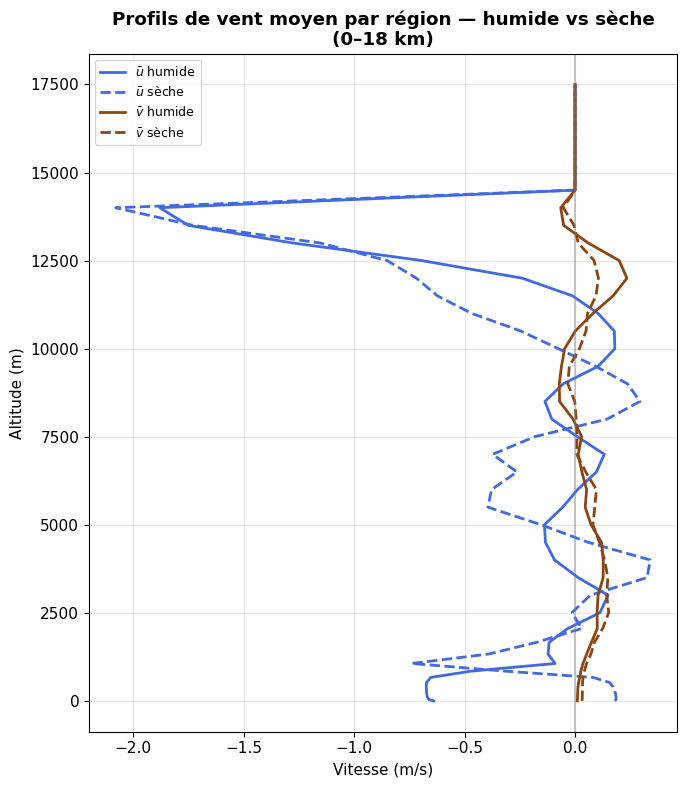

In [16]:
# ======================================================================
# Profils de vent moyen ū et v̄ par région (humide / sèche)
# ======================================================================

fig, ax = plt.subplots(figsize=(7, 8))
idx_18km = np.searchsorted(alt, 18000)
sl = slice(None, idx_18km)

ax.plot(ubar_h[sl], alt[sl], color='royalblue',   lw=2,               label=r'$\bar{u}$ humide')
ax.plot(ubar_s[sl], alt[sl], color='royalblue',   lw=2, linestyle='--', label=r'$\bar{u}$ sèche')
ax.plot(vbar_h[sl], alt[sl], color='saddlebrown', lw=2,               label=r'$\bar{v}$ humide')
ax.plot(vbar_s[sl], alt[sl], color='saddlebrown', lw=2, linestyle='--', label=r'$\bar{v}$ sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('Vitesse (m/s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Profils de vent moyen par région — humide vs sèche\n(0–18 km)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Paramétrisation selon deux axes 

In [17]:
n_stat_it = n_t - t_stat



iz_lo_glob = np.searchsorted(alt, 2000)
iz_hi_glob = np.searchsorted(alt, 18000)
n_z_fit    = iz_hi_glob - iz_lo_glob
z_fit_ab   = alt[iz_lo_glob:iz_hi_glob]

alpha_h = np.zeros(n_z_fit)
beta_h  = np.zeros(n_z_fit)
alpha_s = np.zeros(n_z_fit)
beta_s  = np.zeros(n_z_fit)

y_mean_h  = np.zeros(n_z_fit)
y_mean_s  = np.zeros(n_z_fit)
yhat_mean_h = np.zeros(n_z_fit)
yhat_mean_s = np.zeros(n_z_fit)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

# ── ubar_glob(iz) : moyenne domaine entier sur l'état stationnaire ────
ubar_glob = np.zeros(n_z_fit)
for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):
    for it in range(t_stat, n_t):
        ubar_glob[i_iz] += ds_u['ua'].isel({dim_t: it, dim_z: iz}).values.mean()
    ubar_glob[i_iz] /= n_stat_it
print('ubar_glob calculé.')

# ── Boucle principale : un niveau à la fois ───────────────────────────
for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):

    iz_lo = iz - 1
    iz_hi = iz + 1
    dz    = alt[iz_hi] - alt[iz_lo]

    u_all = ds_u['ua'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    u_lo  = ds_u['ua'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    u_hi  = ds_u['ua'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values
    w_lo  = ds_w['wa'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    w_hi  = ds_w['wa'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values

    # ── scalaires y(t), x1(t), x2(t) pour chaque région ─────────────
    y_t_h  = np.zeros(n_stat_it) ; y_t_s  = np.zeros(n_stat_it)
    x1_t_h = np.zeros(n_stat_it) ; x1_t_s = np.zeros(n_stat_it)
    x2_t_h = np.zeros(n_stat_it) ; x2_t_s = np.zeros(n_stat_it)

    for i_t in range(n_stat_it):

        # y : divergence du flux Reynolds moyen sur la région
        u_p_lo = u_lo[i_t] - u_lo[i_t].mean()
        w_p_lo = w_lo[i_t] - w_lo[i_t].mean()
        u_p_hi = u_hi[i_t] - u_hi[i_t].mean()
        w_p_hi = w_hi[i_t] - w_hi[i_t].mean()

        flux_lo_h = (rho0[iz_lo] * u_p_lo * w_p_lo)[mh].mean()
        flux_hi_h = (rho0[iz_hi] * u_p_hi * w_p_hi)[mh].mean()
        flux_lo_s = (rho0[iz_lo] * u_p_lo * w_p_lo)[ms].mean()
        flux_hi_s = (rho0[iz_hi] * u_p_hi * w_p_hi)[ms].mean()

        y_t_h[i_t] = -(flux_hi_h - flux_lo_h) / (dz * rho0[iz])
        y_t_s[i_t] = -(flux_hi_s - flux_lo_s) / (dz * rho0[iz])

        # x1 : rho0 * ubar_reg
        x1_t_h[i_t] = rho0[iz] * u_all[i_t][mh].mean()
        x1_t_s[i_t] = rho0[iz] * u_all[i_t][ms].mean()

        # x2 : dz(rho0 * ubar_reg) par différences finies centrées
        x2_t_h[i_t] = (rho0[iz_hi] * u_hi[i_t][mh].mean()
                      - rho0[iz_lo] * u_lo[i_t][mh].mean()) / dz
        x2_t_s[i_t] = (rho0[iz_hi] * u_hi[i_t][ms].mean()
                      - rho0[iz_lo] * u_lo[i_t][ms].mean()) / dz

    # ── OLS sur t par région ──────────────────────────────────────────
    for y_t, x1_t, x2_t, alpha_arr, beta_arr, tag in [
        (y_t_h, x1_t_h, x2_t_h, alpha_h, beta_h, 'h'),
        (y_t_s, x1_t_s, x2_t_s, alpha_s, beta_s, 's'),
    ]:
        S11 = x1_t @ x1_t
        S12 = x1_t @ x2_t
        S22 = x2_t @ x2_t
        b1  = x1_t @ y_t
        b2  = x2_t @ y_t

        det = S11 * S22 - S12 * S12
        a   = ( S22 * b1 - S12 * b2) / det
        b   = (-S12 * b1 + S11 * b2) / det

        if tag == 'h':
            alpha_h[i_iz] = a ; beta_h[i_iz] = b
            y_mean_h[i_iz]    = y_t.mean()
            yhat_mean_h[i_iz] = (a * x1_t + b * x2_t).mean()
        else:
            alpha_s[i_iz] = a ; beta_s[i_iz] = b
            y_mean_s[i_iz]    = y_t.mean()
            yhat_mean_s[i_iz] = (a * x1_t + b * x2_t).mean()

    del u_all, u_lo, u_hi, w_lo, w_hi
    gc.collect()

    if i_iz % 10 == 0:
        print(f'  i_iz={i_iz}/{n_z_fit-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()
print('α(z), β(z) calculés.')


ubar_glob calculé.
  i_iz=0/31  (2055 m)
  i_iz=10/31  (7000 m)
  i_iz=20/31  (12000 m)
  i_iz=30/31  (17000 m)
α(z), β(z) calculés.


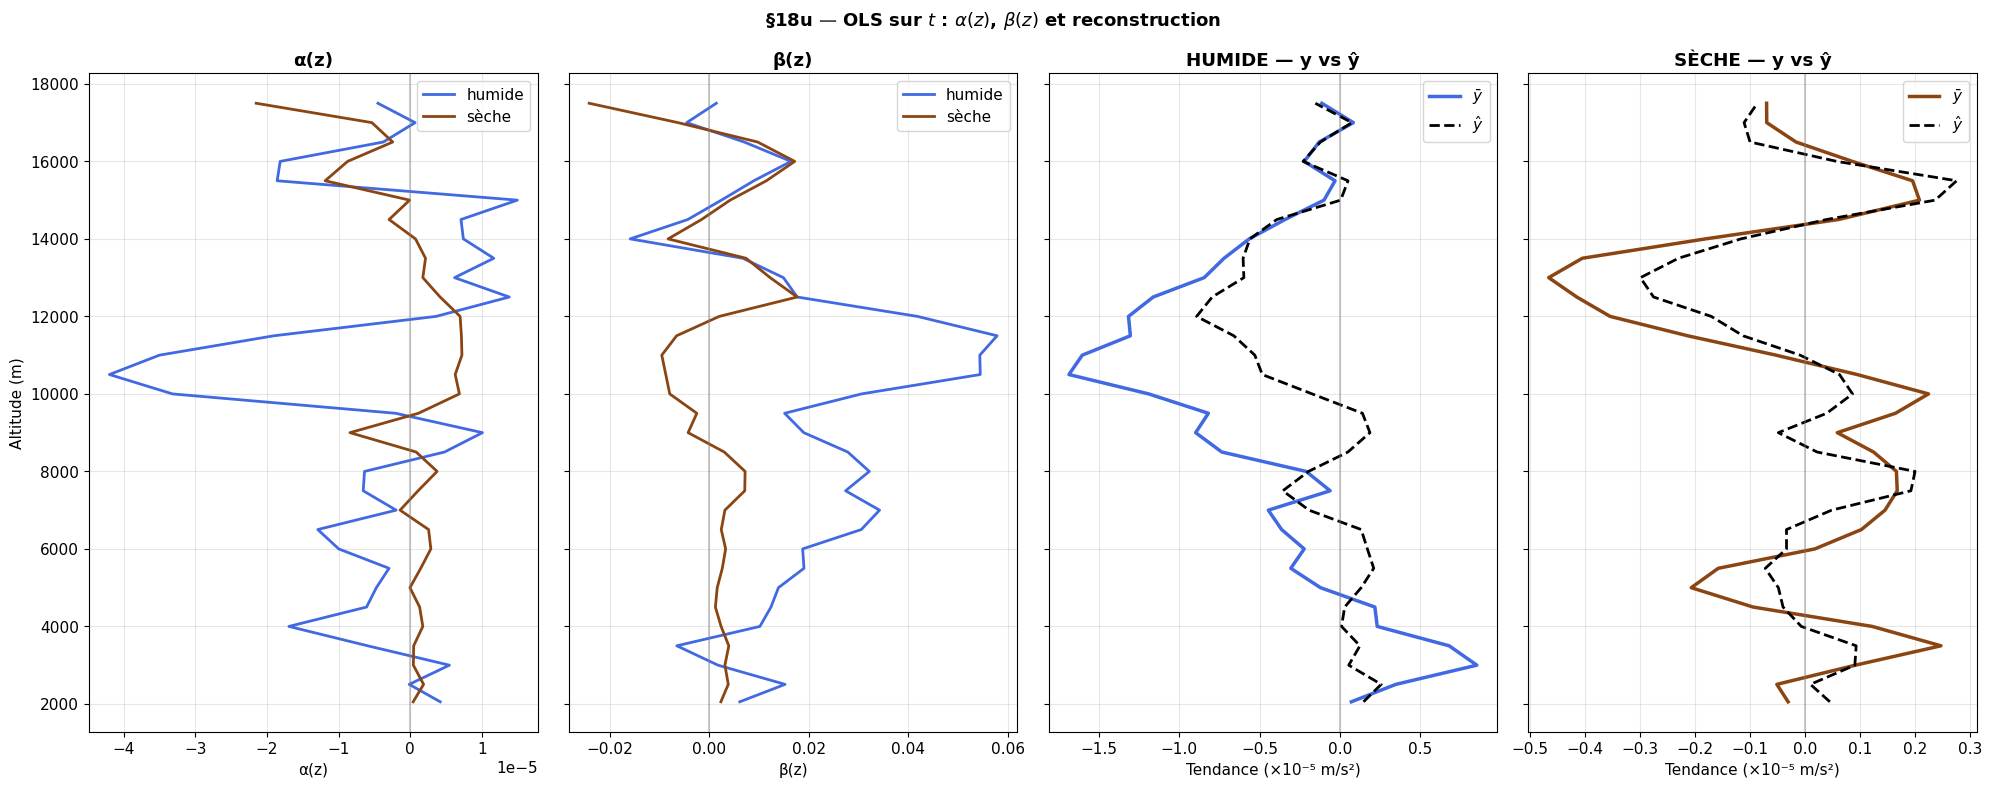

In [18]:
# ── Visualisation α(z) et β(z) + comparaison y vs ŷ ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)

axes[0].plot(alpha_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[0].plot(alpha_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[0].axvline(0, color='grey', alpha=0.4)
axes[0].set_xlabel('α(z)')
axes[0].set_title('α(z)', fontweight='bold')
axes[0].legend() ; axes[0].grid(True, alpha=0.3)

axes[1].plot(beta_h, z_fit_ab, color='royalblue',   lw=2, label='humide')
axes[1].plot(beta_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche')
axes[1].axvline(0, color='grey', alpha=0.4)
axes[1].set_xlabel('β(z)')
axes[1].set_title('β(z)', fontweight='bold')
axes[1].legend() ; axes[1].grid(True, alpha=0.3)

axes[2].plot(y_mean_h    * 1e5, z_fit_ab, color='royalblue', lw=2.5, label=r'$\bar{y}$')
axes[2].plot(yhat_mean_h * 1e5, z_fit_ab, color='black',     lw=2, linestyle='--', label=r'$\hat{y}$')
axes[2].axvline(0, color='grey', alpha=0.4)
axes[2].set_xlabel('Tendance (×10⁻⁵ m/s²)')
axes[2].set_title('HUMIDE — y vs ŷ', fontweight='bold')
axes[2].legend() ; axes[2].grid(True, alpha=0.3)

axes[3].plot(y_mean_s    * 1e5, z_fit_ab, color='saddlebrown', lw=2.5, label=r'$\bar{y}$')
axes[3].plot(yhat_mean_s * 1e5, z_fit_ab, color='black',       lw=2, linestyle='--', label=r'$\hat{y}$')
axes[3].axvline(0, color='grey', alpha=0.4)
axes[3].set_xlabel('Tendance (×10⁻⁵ m/s²)')
axes[3].set_title('SÈCHE — y vs ŷ', fontweight='bold')
axes[3].legend() ; axes[3].grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(r'§18u — OLS sur $t$ : $\alpha(z)$, $\beta(z)$ et reconstruction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# ══════════════════════════════════════════════════════════════════════
# §18v — α(z,t) et β(z,t) via système 2×2 (éq. u + éq. v)
# ══════════════════════════════════════════════════════════════════════

iz_lo_glob = np.searchsorted(alt, 2000)
iz_hi_glob = np.searchsorted(alt, 18000)
n_z_fit    = iz_hi_glob - iz_lo_glob
z_fit_ab   = alt[iz_lo_glob:iz_hi_glob]
n_stat_it  = n_t - t_stat

# résultats : shape (n_z_fit, n_stat_it)
alpha_zt_h = np.full((n_z_fit, n_stat_it), np.nan)
beta_zt_h  = np.full((n_z_fit, n_stat_it), np.nan)
alpha_zt_s = np.full((n_z_fit, n_stat_it), np.nan)
beta_zt_s  = np.full((n_z_fit, n_stat_it), np.nan)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):

    iz_lo = iz - 1
    iz_hi = iz + 1
    dz    = alt[iz_hi] - alt[iz_lo]

    # charger les 3 niveaux nécessaires, tous les pas de temps stat
    u_all = ds_u['ua'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values  # (nt, ny, nx)
    u_lo  = ds_u['ua'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    u_hi  = ds_u['ua'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values
    v_all = ds_v['va'].isel({dim_z: iz,    dim_t: slice(t_stat, n_t)}).values
    v_lo  = ds_v['va'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    v_hi  = ds_v['va'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values
    w_lo  = ds_w['wa'].isel({dim_z: iz_lo, dim_t: slice(t_stat, n_t)}).values
    w_hi  = ds_w['wa'].isel({dim_z: iz_hi, dim_t: slice(t_stat, n_t)}).values

    for i_t in range(n_stat_it):

        # ── anomalies de vent vertical aux niveaux voisins ──
        u_p_lo = u_lo[i_t] - u_lo[i_t].mean()
        u_p_hi = u_hi[i_t] - u_hi[i_t].mean()
        w_p_lo = w_lo[i_t] - w_lo[i_t].mean()
        w_p_hi = w_hi[i_t] - w_hi[i_t].mean()

        # ── membres droits : dz(rho0 * u'w') / rho0 par région ──
        y_u_h = (  (rho0[iz_hi] * u_p_hi * w_p_hi)[mh].mean()
                 - (rho0[iz_lo] * u_p_lo * w_p_lo)[mh].mean() ) / dz
        y_u_s = (  (rho0[iz_hi] * u_p_hi * w_p_hi)[ms].mean()
                 - (rho0[iz_lo] * u_p_lo * w_p_lo)[ms].mean() ) / dz

        # idem pour v
        v_p_lo = v_lo[i_t] - v_lo[i_t].mean()
        v_p_hi = v_hi[i_t] - v_hi[i_t].mean()

        y_v_h = (  (rho0[iz_hi] * v_p_hi * w_p_hi)[mh].mean()
                 - (rho0[iz_lo] * v_p_lo * w_p_lo)[mh].mean() ) / dz
        y_v_s = (  (rho0[iz_hi] * v_p_hi * w_p_hi)[ms].mean()
                 - (rho0[iz_lo] * v_p_lo * w_p_lo)[ms].mean() ) / dz

        # ── membres gauche : rho0*ubar_c et dz(rho0*ubar_c) par région ──
        for mask, tag in [(mh, 'h'), (ms, 's')]:

            # ligne 1 du système (éq. u)
            A11 = rho0[iz] * u_all[i_t][mask].mean()
            A12 = (rho0[iz_hi] * u_hi[i_t][mask].mean()
                 - rho0[iz_lo] * u_lo[i_t][mask].mean()) / dz

            # ligne 2 du système (éq. v)
            A21 = rho0[iz] * v_all[i_t][mask].mean()
            A22 = (rho0[iz_hi] * v_hi[i_t][mask].mean()
                 - rho0[iz_lo] * v_lo[i_t][mask].mean()) / dz

            y1 = y_u_h if tag == 'h' else y_u_s
            y2 = y_v_h if tag == 'h' else y_v_s

            M  = np.array([[A11, A12],
                           [A21, A22]])
            rhs = np.array([y1, y2])

            det = A11 * A22 - A12 * A21
            if np.abs(det) < 1e-30:   # système singulier → NaN
                continue

            sol = np.linalg.solve(M, rhs)

            if tag == 'h':
                alpha_zt_h[i_iz, i_t] = sol[0]
                beta_zt_h [i_iz, i_t] = sol[1]
            else:
                alpha_zt_s[i_iz, i_t] = sol[0]
                beta_zt_s [i_iz, i_t] = sol[1]

    del u_all, u_lo, u_hi, v_all, v_lo, v_hi, w_lo, w_hi
    gc.collect()

    if i_iz % 10 == 0:
        print(f'  i_iz={i_iz}/{n_z_fit-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()
print('α(z,t) et β(z,t) calculés.')

  i_iz=0/31  (2055 m)
  i_iz=10/31  (7000 m)
  i_iz=20/31  (12000 m)
  i_iz=30/31  (17000 m)
α(z,t) et β(z,t) calculés.


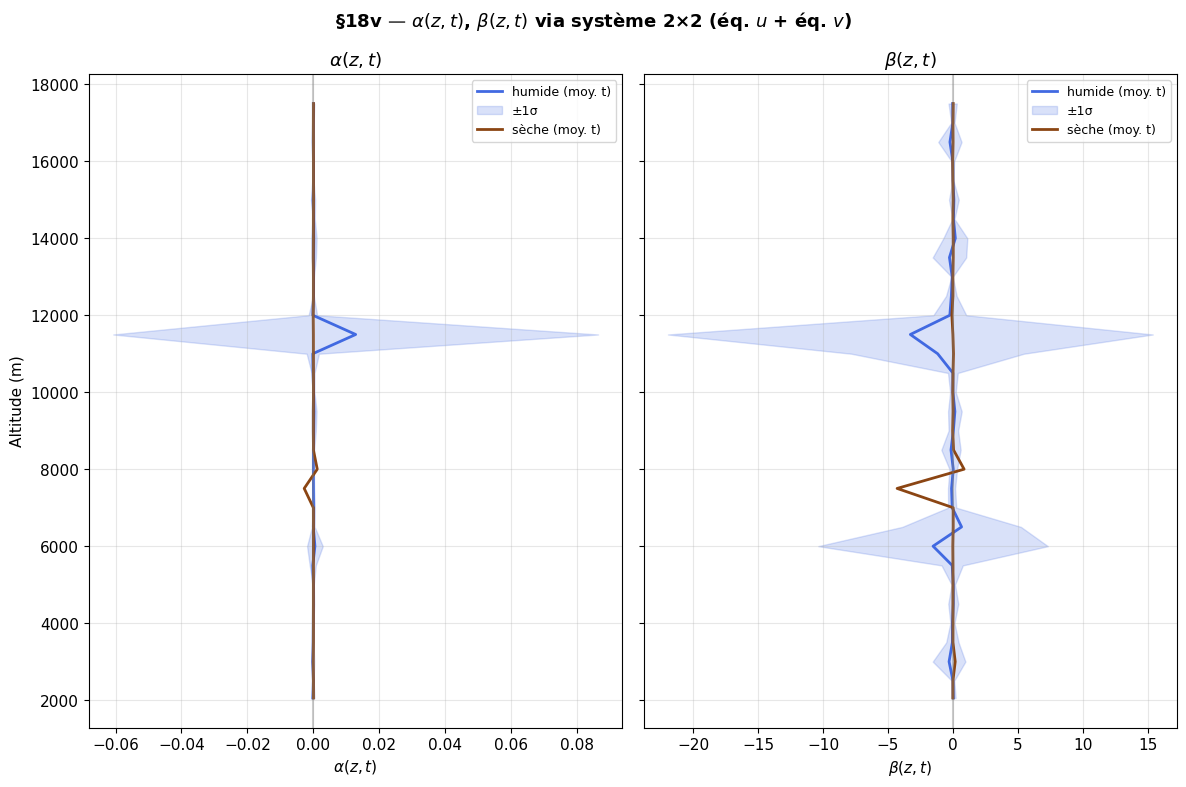

In [20]:
# ── moyenne et écart-type temporels ──
alpha_h_mean = np.nanmean(alpha_zt_h, axis=1)
beta_h_mean  = np.nanmean(beta_zt_h,  axis=1)
alpha_s_mean = np.nanmean(alpha_zt_s, axis=1)
beta_s_mean  = np.nanmean(beta_zt_s,  axis=1)

alpha_h_std  = np.nanstd(alpha_zt_h, axis=1)
beta_h_std   = np.nanstd(beta_zt_h,  axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

for ax, mean_h, std_h, mean_s, lbl in zip(
    axes,
    [alpha_h_mean, beta_h_mean],
    [alpha_h_std,  beta_h_std],
    [alpha_s_mean, beta_s_mean],
    [r'$\alpha(z,t)$', r'$\beta(z,t)$'],
):
    ax.plot(mean_h, z_fit_ab, color='royalblue',   lw=2, label='humide (moy. t)')
    ax.fill_betweenx(z_fit_ab, mean_h - std_h, mean_h + std_h,
                     color='royalblue', alpha=0.2, label='±1σ')
    ax.plot(mean_s, z_fit_ab, color='saddlebrown', lw=2, label='sèche (moy. t)')
    ax.axvline(0, color='grey', alpha=0.4)
    ax.set_xlabel(lbl)
    ax.set_title(lbl, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(r'§18v — $\alpha(z,t)$, $\beta(z,t)$ via système 2×2 (éq. $u$ + éq. $v$)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── Vérification reconstruction §18v ──────────────────────────────────
# Prendre un niveau et un pas de temps arbitraires
i_iz_test = 20
i_t_test  = 5
iz        = iz_lo_glob + i_iz_test
iz_lo     = iz - 1
iz_hi     = iz + 1
dz        = alt[iz_hi] - alt[iz_lo]

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

it = t_stat + i_t_test

u_2d  = ds_u['ua'].isel({dim_t: it, dim_z: iz   }).values
u_lo_ = ds_u['ua'].isel({dim_t: it, dim_z: iz_lo}).values
u_hi_ = ds_u['ua'].isel({dim_t: it, dim_z: iz_hi}).values
v_2d  = ds_v['va'].isel({dim_t: it, dim_z: iz   }).values
v_lo_ = ds_v['va'].isel({dim_t: it, dim_z: iz_lo}).values
v_hi_ = ds_v['va'].isel({dim_t: it, dim_z: iz_hi}).values
w_lo_ = ds_w['wa'].isel({dim_t: it, dim_z: iz_lo}).values
w_hi_ = ds_w['wa'].isel({dim_t: it, dim_z: iz_hi}).values

ds_u.close(); ds_v.close(); ds_w.close()

# ── recalcul y_u et y_v (membres droits) ──
u_p_lo = u_lo_ - u_lo_.mean(); u_p_hi = u_hi_ - u_hi_.mean()
v_p_lo = v_lo_ - v_lo_.mean(); v_p_hi = v_hi_ - v_hi_.mean()
w_p_lo = w_lo_ - w_lo_.mean(); w_p_hi = w_hi_ - w_hi_.mean()

y_u_h = ((rho0[iz_hi]*u_p_hi*w_p_hi)[mh].mean()
        - (rho0[iz_lo]*u_p_lo*w_p_lo)[mh].mean()) / dz
y_v_h = ((rho0[iz_hi]*v_p_hi*w_p_hi)[mh].mean()
        - (rho0[iz_lo]*v_p_lo*w_p_lo)[mh].mean()) / dz

# ── recalcul x1, x2 pour u et v (membres gauches) ──
x1_u = rho0[iz] * u_2d[mh].mean()
x2_u = (rho0[iz_hi]*u_hi_[mh].mean() - rho0[iz_lo]*u_lo_[mh].mean()) / dz
x1_v = rho0[iz] * v_2d[mh].mean()
x2_v = (rho0[iz_hi]*v_hi_[mh].mean() - rho0[iz_lo]*v_lo_[mh].mean()) / dz

# ── reconstruction ──
a = alpha_zt_h[i_iz_test, i_t_test]
b = beta_zt_h [i_iz_test, i_t_test]

yhat_u = a * x1_u + b * x2_u
yhat_v = a * x1_v + b * x2_v

print(f'Niveau z = {alt[iz]:.0f} m,  pas de temps i_t = {i_t_test}')
print(f'  α = {a:.6e},  β = {b:.6e}')
print()
print(f'  y_u  = {y_u_h:.6e}   ŷ_u  = {yhat_u:.6e}   Δ = {abs(y_u_h - yhat_u):.2e}')
print(f'  y_v  = {y_v_h:.6e}   ŷ_v  = {yhat_v:.6e}   Δ = {abs(y_v_h - yhat_v):.2e}')

Niveau z = 12000 m,  pas de temps i_t = 5
  α = 4.282228e-05,  β = -4.333869e-02

  y_u  = 4.567904e-06   ŷ_u  = 4.567904e-06   Δ = 8.47e-22
  y_v  = 3.672460e-06   ŷ_v  = 3.672460e-06   Δ = 4.24e-22


/tmp/ipykernel_5754/3435710634.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


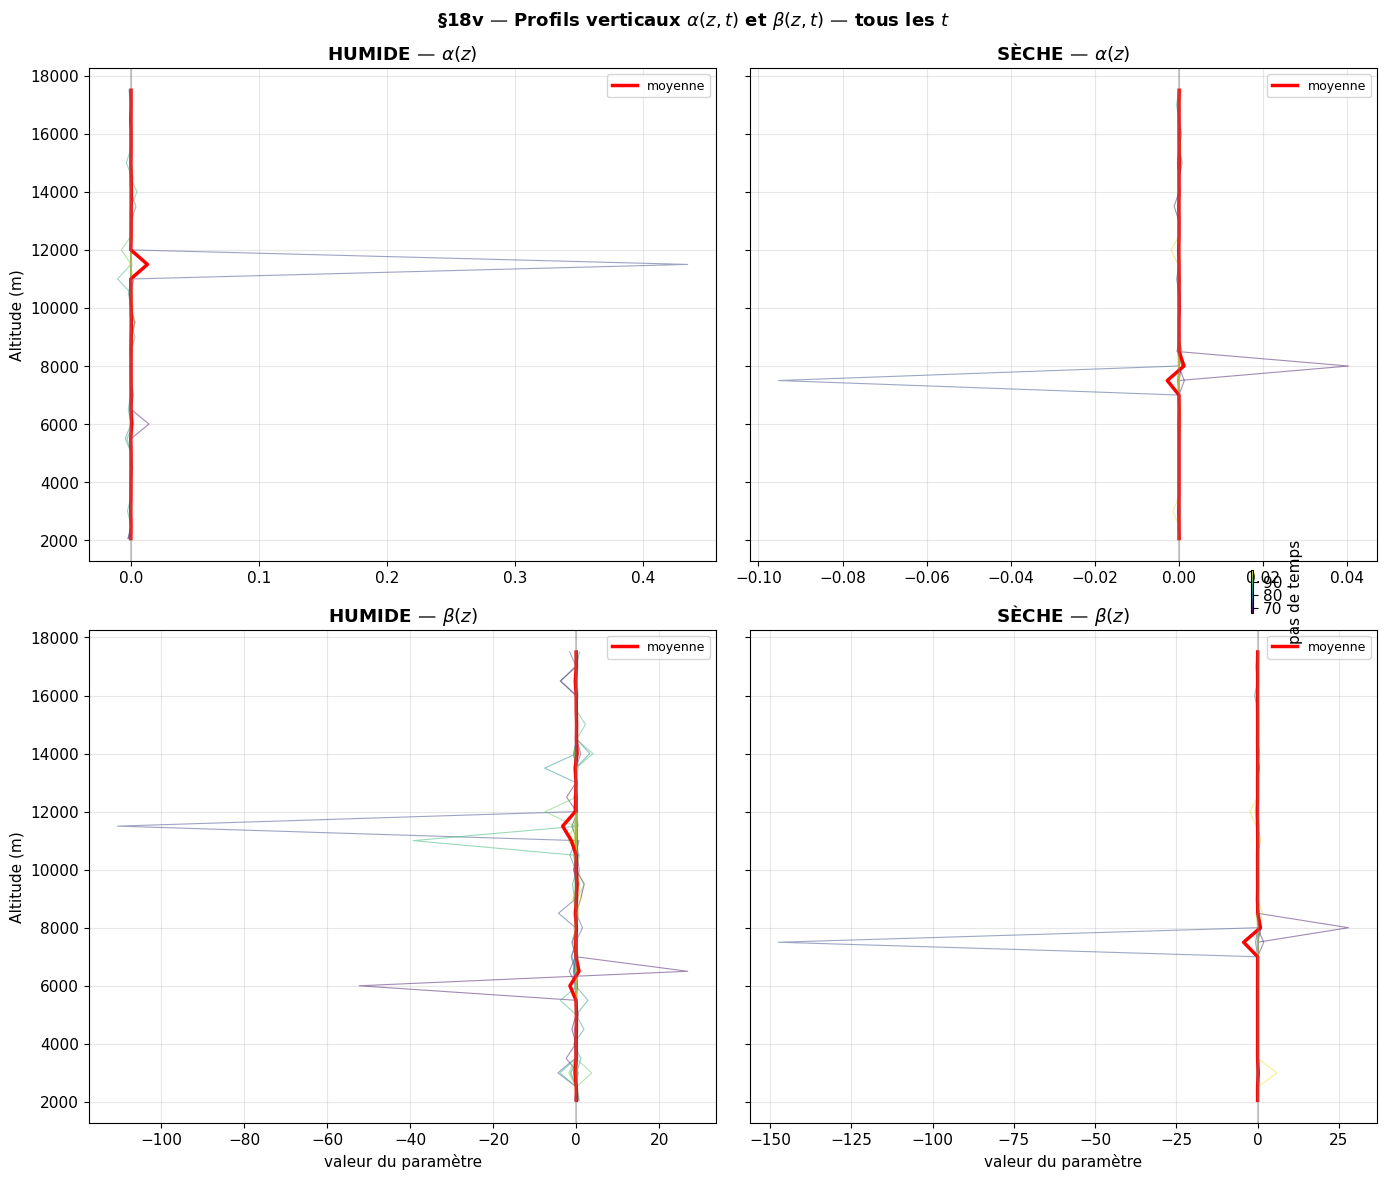

In [25]:
i_t_show = np.arange(n_stat_it)
cmap     = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)
titles = [('HUMIDE', alpha_zt_h, beta_zt_h),
          ('SÈCHE',  alpha_zt_s, beta_zt_s)]

for col, (region, alpha_zt, beta_zt) in enumerate(titles):
    for k, i_t in enumerate(i_t_show):
        c = cmap(k / (n_stat_it - 1))
        axes[0, col].plot(alpha_zt[:, i_t], z_fit_ab, color=c, lw=0.8, alpha=0.5)
        axes[1, col].plot(beta_zt[:, i_t],  z_fit_ab, color=c, lw=0.8, alpha=0.5)

    # moyenne temporelle par-dessus
    axes[0, col].plot(np.nanmean(alpha_zt, axis=1), z_fit_ab,
                      color='red', lw=2.5, label='moyenne')
    axes[1, col].plot(np.nanmean(beta_zt,  axis=1), z_fit_ab,
                      color='red', lw=2.5, label='moyenne')

    for row, lbl in enumerate([r'$\alpha(z)$', r'$\beta(z)$']):
        axes[row, col].axvline(0, color='grey', alpha=0.4)
        axes[row, col].set_title(f'{region} — {lbl}', fontweight='bold')
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].legend(fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel('Altitude (m)')

    axes[1, col].set_xlabel('valeur du paramètre')

sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=t_stat, vmax=t_stat + n_stat_it - 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.002, pad=0.002,
             label='pas de temps')
plt.suptitle(r'§18v — Profils verticaux $\alpha(z,t)$ et $\beta(z,t)$ — tous les $t$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


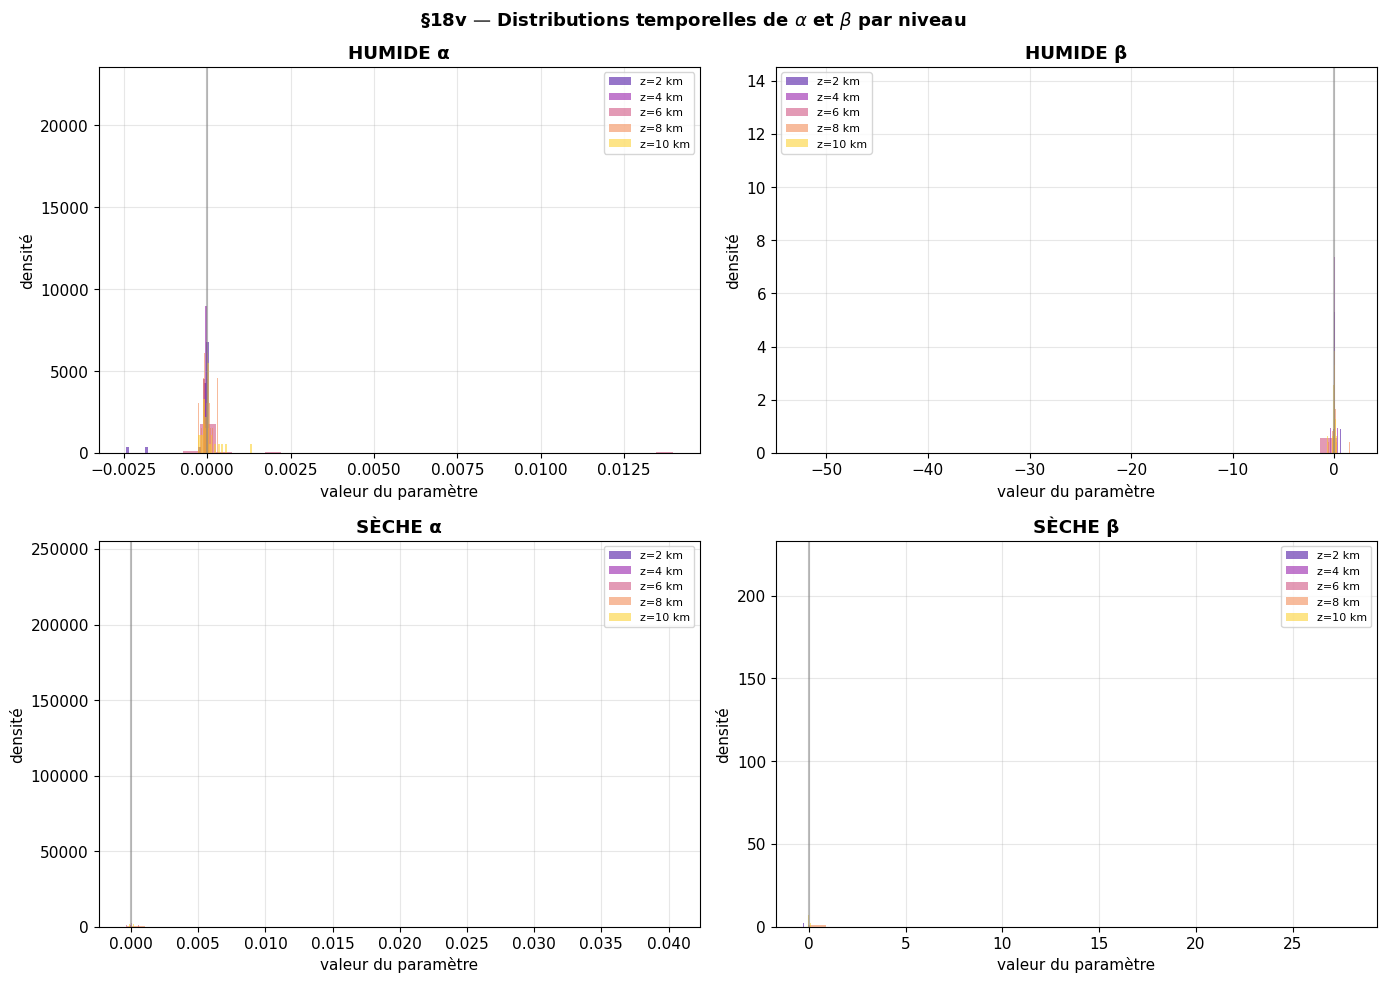

In [23]:
# ── Figure 2 : distributions temporelles à quelques z choisis ─────────
z_targets  = [2000, 4000, 6000, 8000, 10000]  # altitudes cibles (m)
iz_targets = [np.argmin(np.abs(z_fit_ab - zt)) for zt in z_targets]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [('HUMIDE α', alpha_zt_h, axes[0, 0]),
         ('HUMIDE β', beta_zt_h,  axes[0, 1]),
         ('SÈCHE α',  alpha_zt_s, axes[1, 0]),
         ('SÈCHE β',  beta_zt_s,  axes[1, 1])]

colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(iz_targets)))

for title, arr, ax in pairs:
    for iz_t, zt, c in zip(iz_targets, z_targets, colors_z):
        data = arr[iz_t, :]
        data = data[~np.isnan(data)]
        ax.hist(data, bins=30, color=c, alpha=0.55, density=True,
                label=f'z={zt//1000} km')
    ax.axvline(0, color='grey', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('valeur du paramètre')
    ax.set_ylabel('densité')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(r'§18v — Distributions temporelles de $\alpha$ et $\beta$ par niveau',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5754/2408183399.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


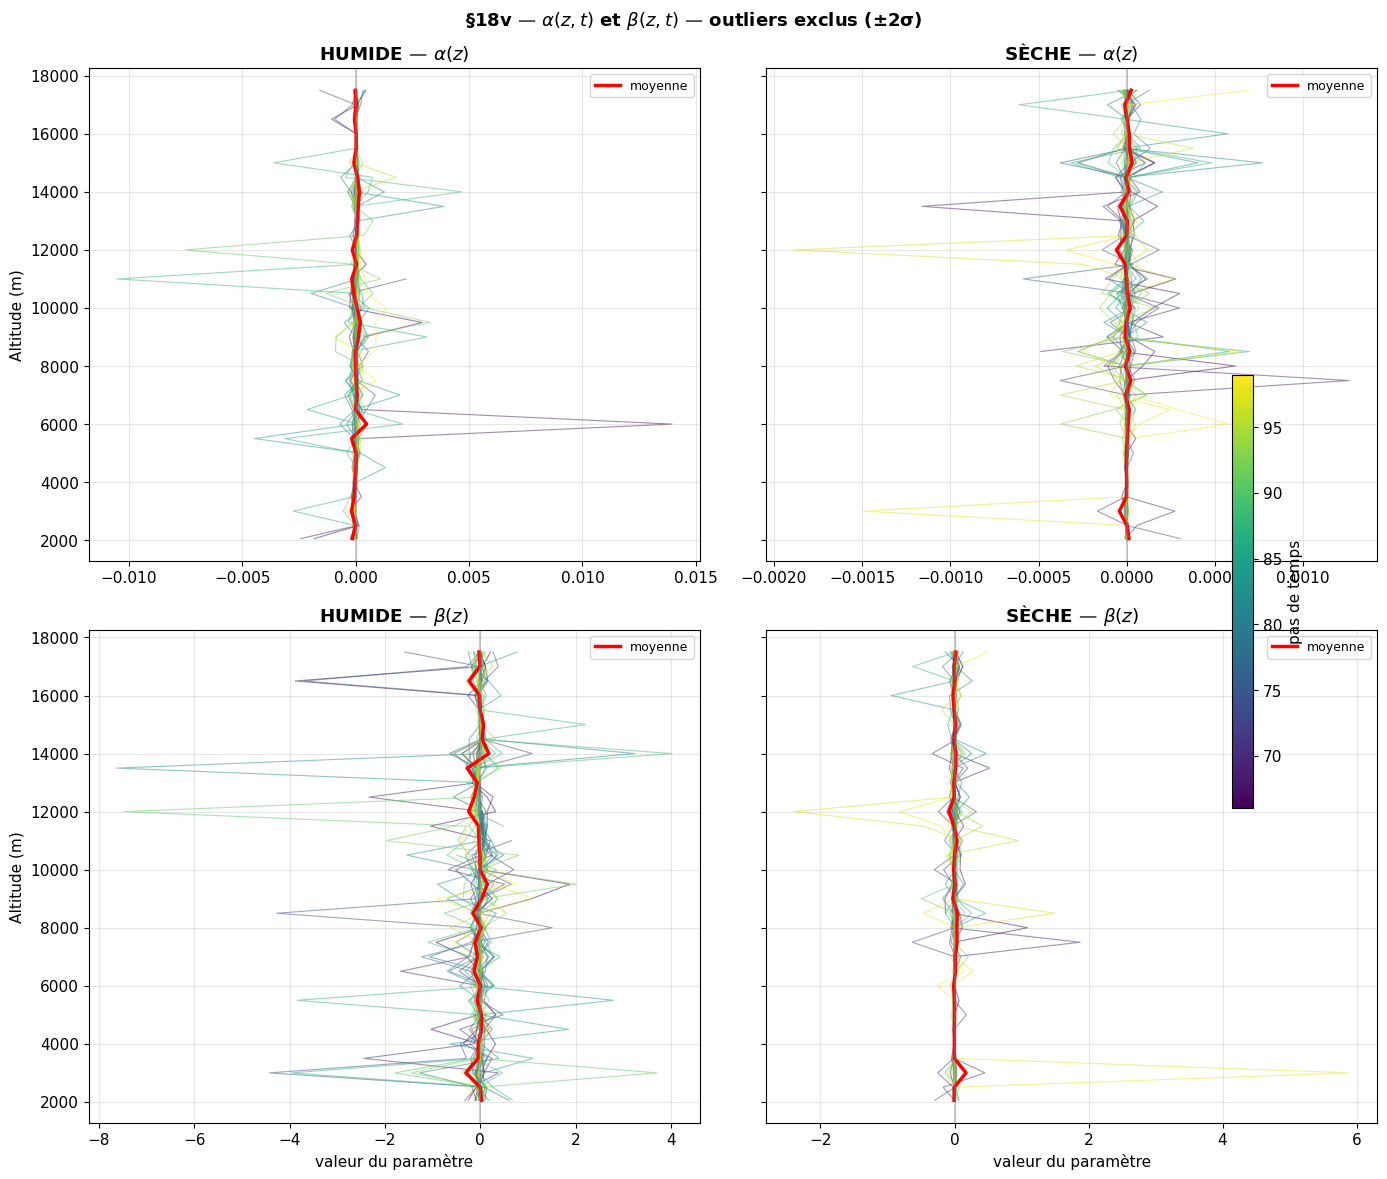

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)
titles = [('HUMIDE', alpha_zt_h, beta_zt_h),
          ('SÈCHE',  alpha_zt_s, beta_zt_s)]

for col, (region, alpha_zt, beta_zt) in enumerate(titles):
    for row, (arr, lbl) in enumerate([(alpha_zt, r'$\alpha(z)$'),
                                       (beta_zt,  r'$\beta(z)$')]):
        ax = axes[row, col]

        # ── seuils ±3σ globaux (sur tous z et t) ──
        mu  = np.nanmean(arr)
        sig = np.nanstd(arr)
        lo, hi = mu - 2*sig, mu + 2*sig

        for k in range(n_stat_it):
            profil = arr[:, k].copy()
            profil[(profil < lo) | (profil > hi)] = np.nan
            c = cmap(k / (n_stat_it - 1))
            ax.plot(profil, z_fit_ab, color=c, lw=0.8, alpha=0.5)

        # moyenne temporelle (après filtrage)
        arr_filt = arr.copy()
        arr_filt[(arr_filt < lo) | (arr_filt > hi)] = np.nan
        ax.plot(np.nanmean(arr_filt, axis=1), z_fit_ab,
                color='red', lw=2.5, label='moyenne')

        ax.axvline(0, color='grey', alpha=0.4)
        ax.set_title(f'{region} — {lbl}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        if col == 0:
            ax.set_ylabel('Altitude (m)')
        if row == 1:
            ax.set_xlabel('valeur du paramètre')

sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=t_stat, vmax=t_stat + n_stat_it - 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02,
             label='pas de temps')
plt.suptitle(r'§18v — $\alpha(z,t)$ et $\beta(z,t)$ — outliers exclus (±2σ)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

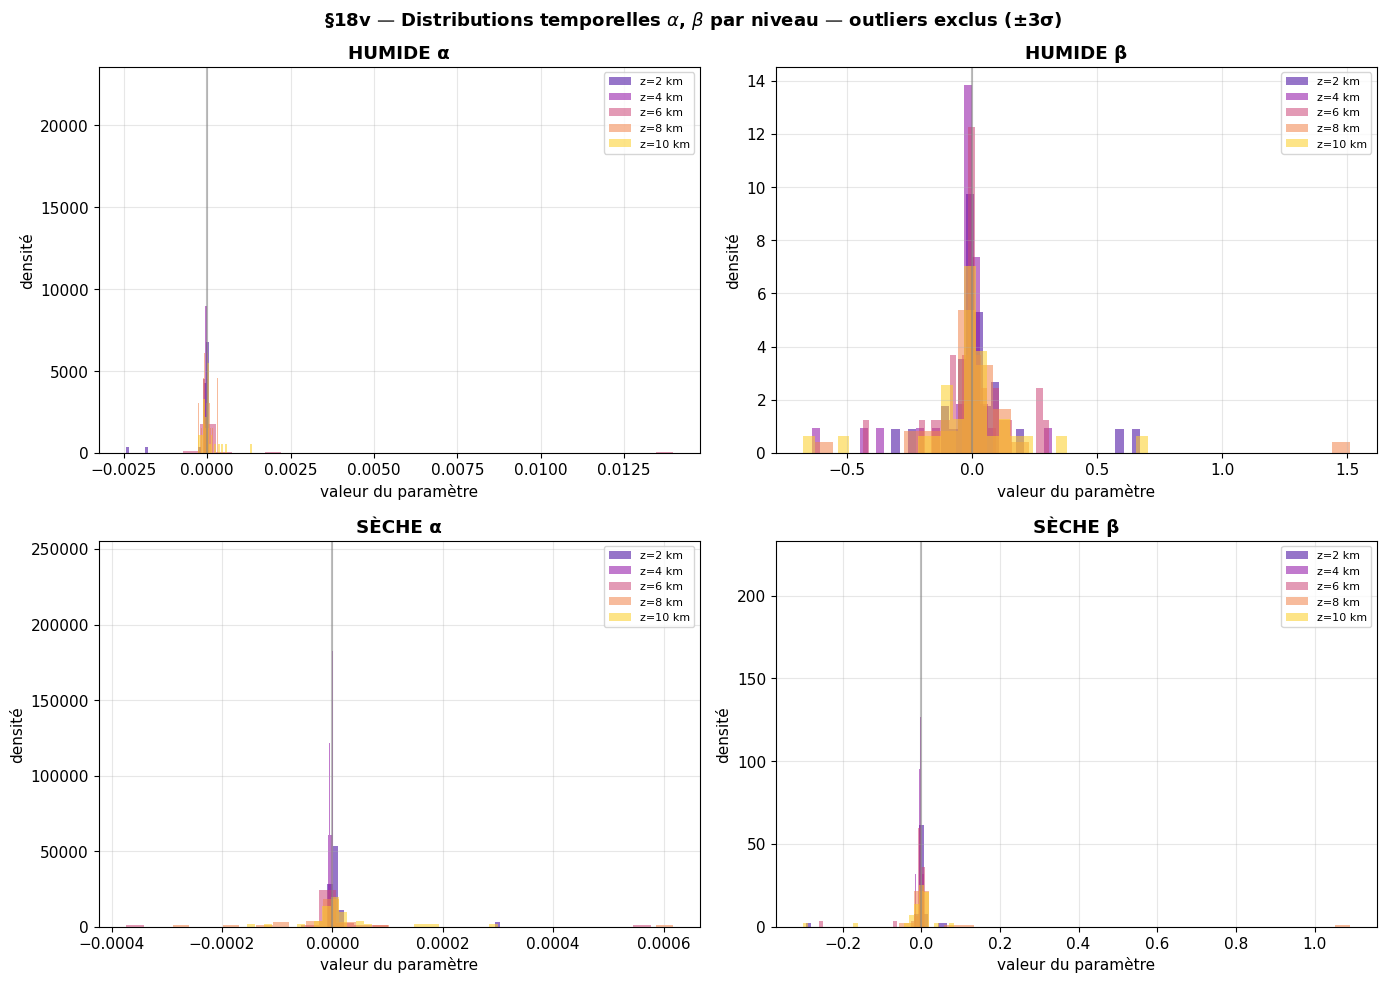

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [('HUMIDE α', alpha_zt_h, axes[0, 0]),
         ('HUMIDE β', beta_zt_h,  axes[0, 1]),
         ('SÈCHE α',  alpha_zt_s, axes[1, 0]),
         ('SÈCHE β',  beta_zt_s,  axes[1, 1])]

colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(iz_targets)))

for title, arr, ax in pairs:
    # ── filtre ±3σ global ──
    mu  = np.nanmean(arr)
    sig = np.nanstd(arr)
    lo, hi = mu - 2*sig, mu + 2*sig
    arr_filt = arr.copy()
    arr_filt[(arr_filt < lo) | (arr_filt > hi)] = np.nan

    for iz_t, zt, c in zip(iz_targets, z_targets, colors_z):
        data = arr_filt[iz_t, :]
        data = data[~np.isnan(data)]
        ax.hist(data, bins=30, color=c, alpha=0.55, density=True,
                label=f'z={zt//1000} km')

    ax.axvline(0, color='grey', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('valeur du paramètre')
    ax.set_ylabel('densité')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(r'§18v — Distributions temporelles $\alpha$, $\beta$ par niveau — outliers exclus (±3σ)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  i_iz=0/31  (2055 m)
  i_iz=10/31  (7000 m)
  i_iz=20/31  (12000 m)
  i_iz=30/31  (17000 m)
dz_flux calculés.


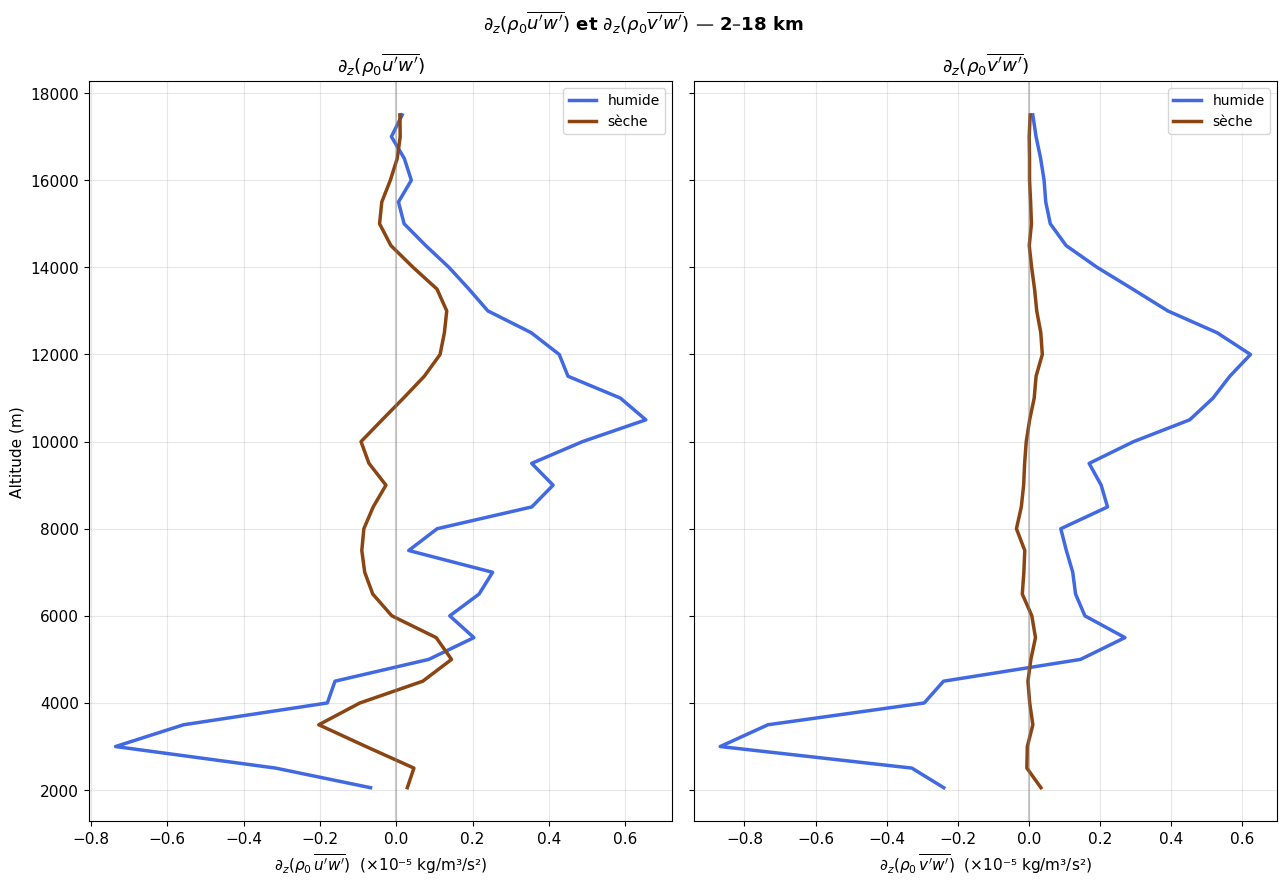

In [39]:
# ── Moyennes temporelles de dz(rho0 u'w') et dz(rho0 v'w') par région ─
dz_flux_u_h = np.zeros(n_z_fit)
dz_flux_u_s = np.zeros(n_z_fit)
dz_flux_v_h = np.zeros(n_z_fit)
dz_flux_v_s = np.zeros(n_z_fit)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for i_iz, iz in enumerate(range(iz_lo_glob, iz_hi_glob)):

    iz_lo = iz - 1
    iz_hi = iz + 1
    dz    = alt[iz_hi] - alt[iz_lo]

    acc_u_h = 0.0 ; acc_u_s = 0.0
    acc_v_h = 0.0 ; acc_v_s = 0.0
    n = 0

    for it in range(t_stat, n_t):
        u_lo_ = ds_u['ua'].isel({dim_t: it, dim_z: iz_lo}).values
        u_hi_ = ds_u['ua'].isel({dim_t: it, dim_z: iz_hi}).values
        v_lo_ = ds_v['va'].isel({dim_t: it, dim_z: iz_lo}).values
        v_hi_ = ds_v['va'].isel({dim_t: it, dim_z: iz_hi}).values
        w_lo_ = ds_w['wa'].isel({dim_t: it, dim_z: iz_lo}).values
        w_hi_ = ds_w['wa'].isel({dim_t: it, dim_z: iz_hi}).values

        u_p_lo = u_lo_ - u_lo_.mean() ; u_p_hi = u_hi_ - u_hi_.mean()
        v_p_lo = v_lo_ - v_lo_.mean() ; v_p_hi = v_hi_ - v_hi_.mean()
        w_p_lo = w_lo_ - w_lo_.mean() ; w_p_hi = w_hi_ - w_hi_.mean()

        acc_u_h += ((rho0[iz_hi]*u_p_hi*w_p_hi)[mh].mean()
                  - (rho0[iz_lo]*u_p_lo*w_p_lo)[mh].mean()) / dz
        acc_u_s += ((rho0[iz_hi]*u_p_hi*w_p_hi)[ms].mean()
                  - (rho0[iz_lo]*u_p_lo*w_p_lo)[ms].mean()) / dz
        acc_v_h += ((rho0[iz_hi]*v_p_hi*w_p_hi)[mh].mean()
                  - (rho0[iz_lo]*v_p_lo*w_p_lo)[mh].mean()) / dz
        acc_v_s += ((rho0[iz_hi]*v_p_hi*w_p_hi)[ms].mean()
                  - (rho0[iz_lo]*v_p_lo*w_p_lo)[ms].mean()) / dz
        n += 1
        del u_lo_, u_hi_, v_lo_, v_hi_, w_lo_, w_hi_
        del u_p_lo, u_p_hi, v_p_lo, v_p_hi, w_p_lo, w_p_hi
        gc.collect()

    dz_flux_u_h[i_iz] = acc_u_h / n
    dz_flux_u_s[i_iz] = acc_u_s / n
    dz_flux_v_h[i_iz] = acc_v_h / n
    dz_flux_v_s[i_iz] = acc_v_s / n

    if i_iz % 10 == 0:
        print(f'  i_iz={i_iz}/{n_z_fit-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()
print('dz_flux calculés.')

# ── Visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

axes[0].plot(dz_flux_u_h * 1e5, z_fit_ab, color='royalblue',   lw=2.5, label='humide')
axes[0].plot(dz_flux_u_s * 1e5, z_fit_ab, color='saddlebrown', lw=2.5, label='sèche')
axes[0].axvline(0, color='grey', alpha=0.4)
axes[0].set_xlabel(r"$\partial_z(\rho_0\,\overline{u'w'})$  (×10⁻⁵ kg/m³/s²)")
axes[0].set_title(r"$\partial_z(\rho_0\overline{u'w'})$", fontweight='bold')
axes[0].legend(fontsize=10) ; axes[0].grid(True, alpha=0.3)

axes[1].plot(dz_flux_v_h * 1e5, z_fit_ab, color='royalblue',   lw=2.5, label='humide')
axes[1].plot(dz_flux_v_s * 1e5, z_fit_ab, color='saddlebrown', lw=2.5, label='sèche')
axes[1].axvline(0, color='grey', alpha=0.4)
axes[1].set_xlabel(r"$\partial_z(\rho_0\,\overline{v'w'})$  (×10⁻⁵ kg/m³/s²)")
axes[1].set_title(r"$\partial_z(\rho_0\overline{v'w'})$", fontweight='bold')
axes[1].legend(fontsize=10) ; axes[1].grid(True, alpha=0.3)

axes[0].set_ylabel('Altitude (m)')
plt.suptitle(r"$\partial_z(\rho_0\overline{u'w'})$ et $\partial_z(\rho_0\overline{v'w'})$ — 2–18 km",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# §20 — Paramétrisation de la convection : flux de masse $M_c$

On prolonge la paramétrisation du flux de Reynolds (§17–§19) par une analyse du
**flux de masse convectif** $M_c$, en s'appuyant sur les équations *bulk-plume* de
Romps (2014, JAS), reproduites ici pour le profil de vent $\bar v$ (éq. 1–3) :

$$
\partial_z M = (\varepsilon-\delta)\,M
\qquad(1)
$$
$$
\rho\,\partial_t \bar v = \partial_z\!\big[M(\bar v - v_c)\big]
\qquad(2)
$$
$$
\partial_z v_c = \varepsilon(\bar v - v_c) + F/M
\qquad(3)
$$

où $M$ est le flux de masse convectif (kg m⁻² s⁻¹), $\varepsilon$ et $\delta$ les taux
fractionnaires d'entraînement / détraînement (m⁻¹), $\bar v$ le vent moyen, $v_c$ le
vent dans les nuages, et $F$ la force de pression nuage↔environnement.

**Lien-clé avec §17.** Dans la limite de faible fraction nuageuse, l'éq. (2) montre que
le flux de Reynolds **est** le flux de masse fois le contraste de vitesse :

$$
\boxed{\;\rho_0\,\overline{u'w'}(z) \;\approx\; M_c(z)\,\big[\bar u(z) - u_c(z)\big]\;}
$$

L'objet de cette section est donc de :
1. **diagnostiquer** $M_c(z)$ directement depuis `wa` (updrafts convectifs), par région humide / sèche ;
2. **vérifier** l'identité flux de Reynolds $\approx M_c\,(\bar u - u_c)$ ;
3. **tester l'éq. (1)** en diagnostiquant $(\varepsilon-\delta)=\partial_z M/M$ ;
4. **relier** l'amplitude $A$ du fit §17 au flux de masse, et boucler le **budget de quantité de mouvement**.

> ⚠️ Cette section réutilise les variables déjà en mémoire : `alt`, `rho0`, `mh`, `ms`,
> `t_stat`, `n_t`, `n_z`, `dim_t/z/y/x`, `path3d`, `idx_tropo`, `sc`, `profil_cmt`,
> `r2_score`, `z_fit`, et les flux `flux_glob_h/s`. Exécuter d'abord §1–§4 et §17.


## §20.0 — Robustesse numérique du fit

La forme analytique $A\,(z/z_c)(1-z/z_c)^n$ lève une `RuntimeWarning` quand $z>z_c$
(base négative à une puissance non entière). On la **redéfinit proprement** en bornant
$\xi=z/z_c\in[0,1]$ : identique sur le domaine utile $z\le z_c$, nulle au-delà, sans warning.


In [ ]:
def profil_cmt(z, A, zc, n):
    """Forme analytique CMT : A·(z/zc)·(1 - z/zc)^n, nulle pour z>zc.

    xi est borné dans [0,1] pour éviter (base<0)**n non entier → plus de RuntimeWarning,
    et reproduit exactement l'ancienne définition sur 0<=z<=zc.
    """
    z  = np.asarray(z, dtype=float)
    xi = np.clip(z / zc, 0.0, 1.0)
    return A * xi * (1.0 - xi)**n

# vérification : identique à l'ancienne forme sur le domaine utile
_zt = np.linspace(0, 15000, 200)
print('profil_cmt redéfinie (sans RuntimeWarning).')
print('  max |f| (A=1, zc=12km, n=1.5) =', np.abs(profil_cmt(_zt, 1.0, 12000., 1.5)).max())


## §20.1 — Définition du flux de masse convectif

Faute de champ de condensat disponible ici, on définit les **cœurs convectifs** par un
critère dynamique sur la vitesse verticale (cf. Romps : updrafts = air montant cohérent) :

$$
M_c(z) \;=\; \rho_0(z)\,\big\langle w \big\rangle_{\text{updraft}}
\quad\text{avec}\quad
\text{updraft} : w > w_{\text{seuil}}(z).
$$

On retient un seuil adaptatif **par niveau** $w_\text{seuil}(z)=\max(w_0,\,c\,\sigma_w(z))$ :
robuste à la décroissance de $\sigma_w$ avec l'altitude. On calcule en parallèle :

- $M^{+}=\rho_0\langle w\rangle_{w>w_s}$ (updrafts),
- $M^{-}=\rho_0\langle w\rangle_{w<-w_s}$ (downdrafts),
- $M_{\text{net}}=\rho_0\,\overline{w}$ (devrait être $\approx 0$ : continuité de masse en RCE),

le tout **par région** humide (`mh`) / sèche (`ms`), niveau par niveau pour la RAM.


In [ ]:
# ── Paramètres du diagnostic de flux de masse ────────────────────────
W0_MIN  = 0.5     # seuil plancher (m/s) pour qualifier un updraft
C_SIGMA = 1.0     # multiplicateur de l'écart-type local sigma_w(z)

# tableaux résultats (par niveau, moyennés sur l'état stationnaire)
Mc_up_h   = np.zeros(n_z) ; Mc_up_s   = np.zeros(n_z)   # M+  (updrafts)
Mc_dn_h   = np.zeros(n_z) ; Mc_dn_s   = np.zeros(n_z)   # M-  (downdrafts)
Mc_net_h  = np.zeros(n_z) ; Mc_net_s  = np.zeros(n_z)   # rho0 * wbar
sigw_h    = np.zeros(n_z) ; sigw_s    = np.zeros(n_z)   # sigma_w(z) par région
frac_up_h = np.zeros(n_z) ; frac_up_s = np.zeros(n_z)   # fraction surfacique updraft

ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    acc_up_h = acc_up_s = 0.0
    acc_dn_h = acc_dn_s = 0.0
    acc_net_h = acc_net_s = 0.0
    acc_sw_h = acc_sw_s = 0.0
    acc_fr_h = acc_fr_s = 0.0
    n = 0

    for it in range(t_stat, n_t):
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values
        w_h  = w_2d[mh] ; w_s = w_2d[ms]

        sw_h = w_h.std() ; sw_s = w_s.std()
        ws_h = max(W0_MIN, C_SIGMA * sw_h)
        ws_s = max(W0_MIN, C_SIGMA * sw_s)

        up_h = w_h[w_h >  ws_h] ; dn_h = w_h[w_h < -ws_h]
        up_s = w_s[w_s >  ws_s] ; dn_s = w_s[w_s < -ws_s]

        # moyennes conditionnelles (0 si aucun point)
        acc_up_h += up_h.mean() if up_h.size else 0.0
        acc_up_s += up_s.mean() if up_s.size else 0.0
        acc_dn_h += dn_h.mean() if dn_h.size else 0.0
        acc_dn_s += dn_s.mean() if dn_s.size else 0.0

        acc_net_h += w_h.mean() ; acc_net_s += w_s.mean()
        acc_sw_h  += sw_h       ; acc_sw_s  += sw_s
        acc_fr_h  += up_h.size / w_h.size
        acc_fr_s  += up_s.size / w_s.size
        n += 1
        del w_2d, w_h, w_s, up_h, up_s, dn_h, dn_s
        gc.collect()

    Mc_up_h[iz]  = rho0[iz] * acc_up_h  / n
    Mc_up_s[iz]  = rho0[iz] * acc_up_s  / n
    Mc_dn_h[iz]  = rho0[iz] * acc_dn_h  / n
    Mc_dn_s[iz]  = rho0[iz] * acc_dn_s  / n
    Mc_net_h[iz] = rho0[iz] * acc_net_h / n
    Mc_net_s[iz] = rho0[iz] * acc_net_s / n
    sigw_h[iz]   = acc_sw_h / n ; sigw_s[iz] = acc_sw_s / n
    frac_up_h[iz]= acc_fr_h / n ; frac_up_s[iz] = acc_fr_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_w.close() ; del ds_w ; gc.collect()
print('Flux de masse Mc (up/down/net) calculés par région.')


## §20.2 — Profils du flux de masse convectif

Lecture attendue : $M^{+}$ positif (transport de masse vers le haut), maximal dans la
basse/moyenne troposphère où la convection est active, surtout en région **humide**.
$M_{\text{net}}\approx 0$ confirme la fermeture de masse (subsidence compensatoire).


In [ ]:
scM = 1e3  # kg/m2/s -> 1e-3
idx18 = np.searchsorted(alt, 18000)

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

# (a) M+ et M- par région
ax = axes[0]
ax.plot(Mc_up_h[:idx18]*scM, alt[:idx18], color='royalblue',   lw=2.5, label='M⁺ humide')
ax.plot(Mc_up_s[:idx18]*scM, alt[:idx18], color='saddlebrown', lw=2.5, label='M⁺ sèche')
ax.plot(Mc_dn_h[:idx18]*scM, alt[:idx18], color='royalblue',   lw=1.8, ls='--', label='M⁻ humide')
ax.plot(Mc_dn_s[:idx18]*scM, alt[:idx18], color='saddlebrown', lw=1.8, ls='--', label='M⁻ sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$M^{\pm}$  (×10⁻³ kg m⁻² s⁻¹)')
ax.set_title('Updrafts / downdrafts', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)
ax.set_ylabel('Altitude (m)')

# (b) M_net (continuité)
ax = axes[1]
ax.plot(Mc_net_h[:idx18]*scM, alt[:idx18], color='royalblue',   lw=2.5, label='humide')
ax.plot(Mc_net_s[:idx18]*scM, alt[:idx18], color='saddlebrown', lw=2.5, label='sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$M_{net}=\rho_0\bar w$  (×10⁻³)')
ax.set_title(r'Flux net ($\approx 0$ attendu)', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)

# (c) fraction updraft et sigma_w
ax = axes[2]
ax.plot(frac_up_h[:idx18]*100, alt[:idx18], color='royalblue',   lw=2.5, label='frac. up humide (%)')
ax.plot(frac_up_s[:idx18]*100, alt[:idx18], color='saddlebrown', lw=2.5, label='frac. up sèche (%)')
ax2 = ax.twiny()
ax2.plot(sigw_h[:idx18], alt[:idx18], color='seagreen', lw=1.5, ls=':', label=r'$\sigma_w$ humide')
ax2.set_xlabel(r'$\sigma_w$ (m/s)', color='seagreen')
ax.set_xlabel('Fraction updraft (%)')
ax.set_title('Couverture convective', fontweight='bold')
ax.legend(fontsize=8, loc='upper right') ; ax.grid(True, alpha=0.3)

plt.suptitle('§20 — Flux de masse convectif diagnostiqué (état stationnaire)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# repères chiffrés
iz10 = np.argmin(np.abs(alt-10000))
print(f"M⁺ humide : max = {Mc_up_h[:idx18].max()*scM:.3f} ×10⁻³  à z={alt[np.argmax(Mc_up_h[:idx18])]:.0f} m")
print(f"M⁺ sèche  : max = {Mc_up_s[:idx18].max()*scM:.3f} ×10⁻³  à z={alt[np.argmax(Mc_up_s[:idx18])]:.0f} m")
print(f"|M_net| humide moyen (0-18km) = {np.abs(Mc_net_h[:idx18]).mean()*scM:.4f} ×10⁻³  (≈0 attendu)")
print(f"M/rho0 humide @~2km : {Mc_up_h[np.argmin(np.abs(alt-2000))]/rho0[np.argmin(np.abs(alt-2000))]*100:.2f} cm/s  (réf. Romps ~1 cm/s)")


---
# §21 — Vérification de l'identité flux de Reynolds ↔ flux de masse

D'après l'éq. (2), le flux de moment vertical s'écrit $M(\bar u - u_c)$. On le confronte
au flux de Reynolds **déjà calculé** en §17 (`flux_glob_h/s`). Pour cela on diagnostique
le **vent dans les cœurs convectifs** $u_c$ (moyenne de $u$ conditionnée aux updrafts),
puis on construit

$$
\Phi_{\text{masse}}(z) \;=\; M_c(z)\,\big[\bar u(z)-u_c(z)\big]
\qquad\text{vs.}\qquad
\Phi_{\text{Reynolds}}(z)=\rho_0\,\overline{u'w'}(z).
$$

Un bon accord (signe, amplitude, altitude de l'extremum) valide l'approche *bulk-plume*
comme **fermeture** du flux de Reynolds, et donc la cohérence de la paramétrisation §17.


In [ ]:
# ── u_c (vent dans updrafts), ubar (vent moyen région), par niveau ───
uc_h   = np.zeros(n_z) ; uc_s   = np.zeros(n_z)
ubar_h = np.zeros(n_z) ; ubar_s = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    acc_uc_h = acc_uc_s = 0.0
    acc_ub_h = acc_ub_s = 0.0
    n = 0
    for it in range(t_stat, n_t):
        u_2d = ds_u['ua'].isel({dim_t: it, dim_z: iz}).values
        w_2d = ds_w['wa'].isel({dim_t: it, dim_z: iz}).values

        for mask, ref in [(mh, 'h'), (ms, 's')]:
            u_r = u_2d[mask] ; w_r = w_2d[mask]
            ws  = max(W0_MIN, C_SIGMA * w_r.std())
            up  = w_r > ws
            uc_val = u_r[up].mean() if up.any() else u_r.mean()
            if ref == 'h':
                acc_uc_h += uc_val ; acc_ub_h += u_r.mean()
            else:
                acc_uc_s += uc_val ; acc_ub_s += u_r.mean()
        n += 1
        del u_2d, w_2d
        gc.collect()

    uc_h[iz]   = acc_uc_h / n ; uc_s[iz]   = acc_uc_s / n
    ubar_h[iz] = acc_ub_h / n ; ubar_s[iz] = acc_ub_s / n

    if iz % 10 == 0:
        print(f'  iz={iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close() ; del ds_u, ds_w ; gc.collect()

# flux de masse reconstruit
Phi_masse_h = Mc_up_h * (ubar_h - uc_h)
Phi_masse_s = Mc_up_s * (ubar_s - uc_s)
print('u_c, ubar, et Φ_masse = M⁺·(ūbar - u_c) calculés.')


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
sl = slice(None, idx_tropo)

# (a) contraste de vent ubar - uc
ax = axes[0]
ax.plot((ubar_h-uc_h)[sl], alt[sl], color='royalblue',   lw=2.5, label='humide')
ax.plot((ubar_s-uc_s)[sl], alt[sl], color='saddlebrown', lw=2.5, label='sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$\bar u - u_c$  (m/s)')
ax.set_title('Contraste vent env. / nuage', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)
ax.set_ylabel('Altitude (m)')

# (b) humide : Reynolds vs masse
ax = axes[1]
ax.plot(flux_glob_h[sl]*sc, alt[sl], color='royalblue', lw=2.5, label=r"$\rho_0\overline{u'w'}$ (Reynolds)")
ax.plot(Phi_masse_h[sl]*sc, alt[sl], color='red', lw=2, ls='--', label=r'$M_c(\bar u-u_c)$ (masse)')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'flux  (×10⁻³ kg m⁻² s⁻²)')
ax.set_title('HUMIDE — Reynolds vs masse', fontweight='bold')
ax.legend(fontsize=8) ; ax.grid(True, alpha=0.3)

# (c) sèche
ax = axes[2]
ax.plot(flux_glob_s[sl]*sc, alt[sl], color='saddlebrown', lw=2.5, label=r"$\rho_0\overline{u'w'}$ (Reynolds)")
ax.plot(Phi_masse_s[sl]*sc, alt[sl], color='red', lw=2, ls='--', label=r'$M_c(\bar u-u_c)$ (masse)')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'flux  (×10⁻³ kg m⁻² s⁻²)')
ax.set_title('SÈCHE — Reynolds vs masse', fontweight='bold')
ax.legend(fontsize=8) ; ax.grid(True, alpha=0.3)

plt.suptitle(r'§21 — Identité bulk-plume : $\rho_0\overline{uw}\approx M_c(\bar u-u_c)$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# corrélation quantitative (troposphère)
for tag, fr, fm in [('HUMIDE', flux_glob_h, Phi_masse_h), ('SÈCHE', flux_glob_s, Phi_masse_s)]:
    a = fr[:idx_tropo] ; b = fm[:idx_tropo]
    ok = np.isfinite(a) & np.isfinite(b)
    r  = np.corrcoef(a[ok], b[ok])[0,1]
    ratio = np.nan if np.abs(b[ok]).sum()==0 else (a[ok]@b[ok])/(b[ok]@b[ok])
    print(f'{tag:7s}: corr(Reynolds, masse) = {r:+.3f}   pente OLS (Reynolds/masse) = {ratio:+.3f}')


---
# §22 — Test de l'équation bulk-plume (1) : $\partial_z M = (\varepsilon-\delta)M$

L'éq. (1) définit le taux net d'entraînement/détraînement à partir du seul profil de
flux de masse :

$$
(\varepsilon-\delta)(z) \;=\; \frac{1}{M_c}\,\partial_z M_c .
$$

- $(\varepsilon-\delta)>0$ : couche **d'entraînement** net (le flux de masse croît avec $z$, typiquement en basse troposphère) ;
- $(\varepsilon-\delta)<0$ : couche de **détraînement** net (sommet convectif, le flux décroît).

On compare aussi à l'ordre de grandeur de Romps ($\varepsilon\sim 0.4$–$1.5$ km⁻¹).
On masque les niveaux où $|M_c|$ est trop faible (division instable).


In [ ]:
def eps_minus_delta(M, z, seuil_rel=0.05):
    """(eps - delta) = dz(M)/M, en km^-1, masqué où |M| < seuil_rel*max|M|."""
    M    = np.asarray(M, float)
    dMdz = np.gradient(M, z)              # s^-1 * (kg/m2/s)/m -> par mètre
    seuil = seuil_rel * np.nanmax(np.abs(M))
    ed = np.where(np.abs(M) > seuil, dMdz / M, np.nan)
    return ed * 1000.0                    # m^-1 -> km^-1

ed_h = eps_minus_delta(Mc_up_h, alt)
ed_s = eps_minus_delta(Mc_up_s, alt)

fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)

ax = axes[0]
ax.plot(Mc_up_h[:idx18]*scM, alt[:idx18], color='royalblue',   lw=2.5, label='humide')
ax.plot(Mc_up_s[:idx18]*scM, alt[:idx18], color='saddlebrown', lw=2.5, label='sèche')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$M_c$  (×10⁻³ kg m⁻² s⁻¹)')
ax.set_title(r'Flux de masse $M_c$', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)
ax.set_ylabel('Altitude (m)')

ax = axes[1]
ax.plot(ed_h[:idx18], alt[:idx18], color='royalblue',   lw=2.5, label='humide')
ax.plot(ed_s[:idx18], alt[:idx18], color='saddlebrown', lw=2.5, label='sèche')
ax.axvline(0, color='grey', alpha=0.4)
for v in (0.4, 1.5):
    ax.axvline(v, color='green', alpha=0.3, ls=':')
    ax.axvline(-v, color='red', alpha=0.3, ls=':')
ax.set_xlabel(r'$(\varepsilon-\delta)$  (km⁻¹)')
ax.set_title(r'$\partial_z M_c / M_c$  (vert: entraîn., réf. ±0.4/1.5)', fontweight='bold')
ax.set_xlim(-3, 3)
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)

plt.suptitle(r'§22 — Éq. (1) bulk-plume : taux net $(\varepsilon-\delta)=\partial_z M_c/M_c$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# niveau de transition entraînement -> détraînement (humide)
sub = np.where(np.isfinite(ed_h[:idx18]))[0]
if sub.size:
    sign_change = np.where(np.diff(np.sign(ed_h[sub])) < 0)[0]
    if sign_change.size:
        iz_c = sub[sign_change[0]]
        print(f'Région humide : entraînement→détraînement vers z ≈ {alt[iz_c]:.0f} m')
    print(f'(ε-δ) humide médian basse tropo (0-6km) : '
          f'{np.nanmedian(ed_h[:np.searchsorted(alt,6000)]):+.2f} km⁻¹')


---
# §23 — Paramétrisation de $M_c$ et lien avec l'amplitude $A$ du flux

On applique au flux de masse la **même forme analytique** qu'au flux de Reynolds (§17),
ce qui donne une loi compacte utilisable en GCM :

$$
M_c(z) \;=\; A_M\,\frac{z}{z_{c,M}}\Big(1-\frac{z}{z_{c,M}}\Big)^{n_M}.
$$

Puis on **relie** l'amplitude du flux de Reynolds $A$ (fit §17) à celle du flux de masse.
Via l'identité $\rho_0\overline{u'w'}\approx M_c(\bar u-u_c)$, on attend
$A \sim A_M\cdot\overline{(\bar u-u_c)}$ : l'amplitude du flux de moment est portée par le
flux de masse modulé par le cisaillement effectif nuage/environnement.


In [ ]:
z_fit = alt[:idx_tropo].astype(float)

def fit_cmt(profil, p0=None):
    """Ajuste profil_cmt sur z_fit ; renvoie (popt, R2). p0 auto si None."""
    y = profil[:idx_tropo]
    if p0 is None:
        amp = y[np.argmax(np.abs(y))]
        p0  = [amp, 12000.0, 1.0]
    popt, _ = curve_fit(profil_cmt, z_fit, y, p0=p0, maxfev=20000)
    return popt, r2_score(y, profil_cmt(z_fit, *popt))

popt_Mc_h, R2_Mc_h = fit_cmt(Mc_up_h)
popt_Mc_s, R2_Mc_s = fit_cmt(Mc_up_s)
AM_h, zcM_h, nM_h = popt_Mc_h
AM_s, zcM_s, nM_s = popt_Mc_s

print('── Fit flux de masse M_c (forme CMT) ──')
print(f'  HUMIDE : A_M={AM_h:.4e}  zc={zcM_h/1e3:.2f} km  n={nM_h:.3f}  R²={R2_Mc_h:.4f}')
print(f'  SÈCHE  : A_M={AM_s:.4e}  zc={zcM_s/1e3:.2f} km  n={nM_s:.3f}  R²={R2_Mc_s:.4f}')

fig, ax = plt.subplots(figsize=(7, 9))
ax.plot(Mc_up_h[:idx_tropo]*scM, z_fit, color='royalblue',   lw=2.5, label='M_c humide (sim.)')
ax.plot(profil_cmt(z_fit,*popt_Mc_h)*scM, z_fit, color='red', lw=1.8, ls='--',
        label=f'fit humide R²={R2_Mc_h:.3f}')
ax.plot(Mc_up_s[:idx_tropo]*scM, z_fit, color='saddlebrown', lw=2.5, label='M_c sèche (sim.)')
ax.plot(profil_cmt(z_fit,*popt_Mc_s)*scM, z_fit, color='orange', lw=1.8, ls='--',
        label=f'fit sèche R²={R2_Mc_s:.3f}')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$M_c$  (×10⁻³ kg m⁻² s⁻¹)')
ax.set_ylabel('Altitude (m)')
ax.set_title('§23 — Paramétrisation CMT du flux de masse', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Lien amplitude A (Reynolds) ↔ A_M (masse) via le cisaillement effectif ──
# fit du flux de Reynolds (réutilise §17 si déjà fait, sinon refit propre)
popt_h, R2_h = fit_cmt(flux_glob_h, p0=[flux_glob_h[:idx_tropo].min(), 12000., 1.5])
popt_s, R2_s = fit_cmt(flux_glob_s, p0=[flux_glob_s[:idx_tropo].min(), 12000., 1.5])
A_h, zc_h, n_h = popt_h
A_s, zc_s, n_s = popt_s

# cisaillement effectif moyen (pondéré par M_c, sur la tropo)
def shear_eff(Mc, ubar, uc):
    w = np.abs(Mc[:idx_tropo])
    d = (ubar - uc)[:idx_tropo]
    ok = np.isfinite(d) & (w > 0)
    return np.nan if not ok.any() else np.average(d[ok], weights=w[ok])

du_h = shear_eff(Mc_up_h, ubar_h, uc_h)
du_s = shear_eff(Mc_up_s, ubar_s, uc_s)

print('='*64)
print(f'{"":<26}{"HUMIDE":>18}{"SÈCHE":>18}')
print('='*64)
print(f'{"A  flux Reynolds":<26}{A_h:>18.4e}{A_s:>18.4e}')
print(f'{"A_M flux masse":<26}{AM_h:>18.4e}{AM_s:>18.4e}')
print(f'{"⟨ūbar-u_c⟩ pond. (m/s)":<26}{du_h:>18.4f}{du_s:>18.4f}')
print(f'{"A_M·⟨ūbar-u_c⟩ (prédit A)":<26}{AM_h*du_h:>18.4e}{AM_s*du_s:>18.4e}')
print(f'{"ratio A / (A_M·Δu)":<26}{A_h/(AM_h*du_h):>18.3f}{A_s/(AM_s*du_s):>18.3f}')
print('='*64)
print('\nInterprétation : un ratio proche de 1 valide A ≈ A_M·⟨ūbar-u_c⟩,')
print("i.e. l'amplitude du flux de moment est le flux de masse × cisaillement effectif.")


---
# §24 — Bouclage du budget de quantité de mouvement

Dernier test de cohérence : la tendance de vent moyen donnée par la **divergence du flux
de Reynolds** (déjà utilisée en §16/§18) doit être reproduite par la **divergence du flux
de masse** :

$$
\partial_t \bar u
\;=\; -\frac{1}{\rho_0}\,\partial_z\!\big(\rho_0\,\overline{u'w'}\big)
\;\approx\; -\frac{1}{\rho_0}\,\partial_z\!\big[M_c(\bar u - u_c)\big].
$$

On compare donc, par région, la tendance issue du flux de Reynolds (vérité) à celle issue
du flux de masse (paramétrisation). Bon accord ⇒ la fermeture *bulk-plume* est valide de
bout en bout pour cette simulation `large300`.


In [ ]:
def tendance(flux_profil):
    """Force de Reynolds : -1/rho0 · d(rho0 <u'w'>)/dz  (m/s²)."""
    return -np.gradient(flux_profil, alt) / rho0

tend_rey_h  = tendance(flux_glob_h)
tend_rey_s  = tendance(flux_glob_s)
tend_mass_h = tendance(Phi_masse_h)
tend_mass_s = tendance(Phi_masse_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)
sl = slice(None, idx_tropo)
st = 1e5  # m/s² -> 1e-5

ax = axes[0]
ax.plot(tend_rey_h[sl]*st,  alt[sl], color='royalblue', lw=2.5, label='Reynolds (vérité)')
ax.plot(tend_mass_h[sl]*st, alt[sl], color='red', lw=2, ls='--', label='flux de masse')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$\partial_t\bar u$  (×10⁻⁵ m/s²)')
ax.set_title('HUMIDE', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)
ax.set_ylabel('Altitude (m)')

ax = axes[1]
ax.plot(tend_rey_s[sl]*st,  alt[sl], color='saddlebrown', lw=2.5, label='Reynolds (vérité)')
ax.plot(tend_mass_s[sl]*st, alt[sl], color='red', lw=2, ls='--', label='flux de masse')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel(r'$\partial_t\bar u$  (×10⁻⁵ m/s²)')
ax.set_title('SÈCHE', fontweight='bold')
ax.legend(fontsize=9) ; ax.grid(True, alpha=0.3)

plt.suptitle(r'§24 — Budget QDM : $-\frac{1}{\rho_0}\partial_z(\rho_0\overline{uw})$ '
             r'vs $-\frac{1}{\rho_0}\partial_z[M_c(\bar u-u_c)]$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for tag, tr, tm in [('HUMIDE', tend_rey_h, tend_mass_h), ('SÈCHE', tend_rey_s, tend_mass_s)]:
    a = tr[:idx_tropo] ; b = tm[:idx_tropo]
    ok = np.isfinite(a) & np.isfinite(b)
    r  = np.corrcoef(a[ok], b[ok])[0,1]
    rms= np.sqrt(np.mean((a[ok]-b[ok])**2))
    print(f'{tag:7s}: corr = {r:+.3f}   RMS écart = {rms*st:.3f} ×10⁻⁵ m/s²')


---
# §25 — Synthèse

Cette section a prolongé la paramétrisation du flux de Reynolds par une analyse du **flux
de masse convectif**, en s'appuyant sur les trois équations *bulk-plume* de Romps (2014) :

| Étape | Contenu | Résultat attendu |
|-------|---------|------------------|
| §20 | Diagnostic $M_c=\rho_0\langle w\rangle_{up}$, up/down/net, par région | $M^{+}>0$, $M_{net}\approx0$, $M/\rho_0\sim$ cm/s |
| §21 | Identité $\rho_0\overline{u'w'}\approx M_c(\bar u-u_c)$ | corrélation élevée, pente $\approx1$ |
| §22 | Éq. (1) : $(\varepsilon-\delta)=\partial_z M_c/M_c$ | entraînement bas, détraînement au sommet |
| §23 | Fit CMT de $M_c$ ; lien $A\leftrightarrow A_M$ | $A\approx A_M\langle\bar u-u_c\rangle$ |
| §24 | Bouclage budget QDM | $\partial_t\bar u$ Reynolds vs masse cohérents |

**Pistes de suite** (cf. plan §18–§19) :
- même pipeline sur `small300` puis comparaison croisée des paramètres ($A_M$, $z_{c,M}$, $n_M$) pour tester l'**universalité** ;
- relier $A$ / $A_M$ aux variables grande-échelle (**CAPE**, cisaillement) ;
- raffiner la définition des cœurs convectifs (seuil de condensat si `clw`/`cli` disponibles) ;
- diagnostiquer $\varepsilon$ et $\delta$ séparément via l'éq. (3) et $u_c(z)$.
